# 🔍 Zenlytics — Exploratory Data Analysis (EDA)
**Project:** AI-based Sentiment Analytics for Tokopedia Product Reviews  
**Program:** Pijak × IBM SkillsBuild Capstone Project  
**Peran:** AI Engineer  
**Nama:** Nurhayati Kusumaning Ayu (APC617D6X0220)   
**Input Data:** `Zenlytics_ml_ready_v1.0.csv` (output dari pipeline Data Engineering)  
**Versi EDA:** v1.0  

---

## 🎯 Tujuan Notebook Ini

Notebook ini adalah **langkah WAJIB sebelum modeling** — ibarat seorang dokter yang membaca
hasil lab pasien sebelum memberikan resep obat. Tanpa EDA, model bisa dibangun di atas
asumsi yang salah dan menghasilkan performa yang buruk.

EDA menjawab 5 pertanyaan kunci:

| No | Pertanyaan | Relevansi untuk Modeling |
|---|---|---|
| 1 | Seberapa parah class imbalance-nya? | Menentukan strategi: SMOTE vs class_weight |
| 2 | Bagaimana distribusi fitur numerik? | Menentukan perlu normalisasi atau tidak |
| 3 | Ada korelasi antar fitur? | Menghindari multikolinearitas |
| 4 | Apa kata-kata paling dominan per kelas? | Insight untuk feature engineering teks |
| 5 | Ada pola temporal? | Menentukan apakah `review_year/month` berguna |

---

## 🗺️ Alur EDA (9 Tahap)

| No | Tahap | Output |
|---|---|---|
| 1 | Setup & Load Data | DataFrame siap eksplorasi |
| 2 | Ringkasan Dataset | Overview struktur & statistik |
| 3 | Analisis Class Imbalance | Visualisasi + rasio imbalance |
| 4 | Distribusi Fitur Numerik | Histogram + boxplot per fitur |
| 5 | Analisis Teks (NLP Insight) | WordCloud + top kata per kelas |
| 6 | Analisis Kategorikal | Distribusi kategori produk & harga |
| 7 | Analisis Temporal | Tren ulasan per tahun & bulan |
| 8 | Korelasi Fitur | Heatmap korelasi numerik |
| 9 | Kesimpulan & Rekomendasi Modeling | Panduan untuk notebook selanjutnya |

---
## ⚙️ TAHAP 1 — Setup & Load Data

**Mengapa perlu setup dulu?**  
Sama seperti sebelum memasak — kita siapkan kompor, wajan, dan bahan-bahannya dulu.  
Kalau langsung loncat ke analisis tanpa import library, kode pasti error.

In [1]:
# ============================================================
# INSTALASI LIBRARY TAMBAHAN (jalankan sekali)
# wordcloud : untuk membuat visualisasi kata-kata dominan
# ============================================================
!pip install wordcloud --quiet


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ============================================================
# IMPORT LIBRARY
# ============================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

# Sembunyikan warning tidak penting
warnings.filterwarnings('ignore')

# Konfigurasi tampilan pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Konfigurasi tema visualisasi
# 'seaborn-v0_8-whitegrid' → tampilan bersih dan profesional
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = {
    'positive': '#2ecc71',   # hijau
    'neutral' : '#f39c12',   # oranye
    'negative': '#e74c3c',   # merah
}
COLOR_LIST = [PALETTE['positive'], PALETTE['neutral'], PALETTE['negative']]

print('✅ Semua library berhasil diimpor.')

✅ Semua library berhasil diimpor.


In [3]:
# ============================================================
# KONFIGURASI PATH
# Notebook ini ada di: notebooks/
# ROOT project ada di: satu level di atas (..)
# ============================================================

# os.path.abspath('..') → naik satu tingkat dari /notebooks/ ke root project
BASE_DIR      = os.path.abspath('..')
PROCESSED_DIR = os.path.join(BASE_DIR, 'data', 'processed')
REPORT_DIR    = os.path.abspath(os.path.join(BASE_DIR, 'reports'))

# Path file input — hasil pipeline Data Engineering
ML_READY_PATH = os.path.join(PROCESSED_DIR, 'Zenlytics_ml_ready_v1.0.csv')
TRAIN_PATH    = os.path.join(PROCESSED_DIR, 'Zenlytics_train_v1.0.csv')
TEST_PATH     = os.path.join(PROCESSED_DIR, 'Zenlytics_test_v1.0.csv')

# Buat folder report jika belum ada
os.makedirs(REPORT_DIR, exist_ok=True)

print(f'📁 BASE_DIR      : {BASE_DIR}')
print(f'📂 PROCESSED DIR : {PROCESSED_DIR}')
print(f'📊 REPORT DIR    : {REPORT_DIR}')
print(f'📄 ML_READY_PATH : {ML_READY_PATH}')

📁 BASE_DIR      : d:\capstone-project-pijak
📂 PROCESSED DIR : d:\capstone-project-pijak\data\processed
📊 REPORT DIR    : d:\capstone-project-pijak\reports
📄 ML_READY_PATH : d:\capstone-project-pijak\data\processed\Zenlytics_ml_ready_v1.0.csv


In [4]:
# ============================================================
# LOAD DATA
# Kita load 3 file sekaligus:
#   df       = dataset lengkap ML-ready (untuk EDA)
#   df_train = data latih (80%) — untuk melihat distribusi training
#   df_test  = data uji  (20%) — untuk verifikasi split
# ============================================================

df       = pd.read_csv(ML_READY_PATH)
df_train = pd.read_csv(TRAIN_PATH)
df_test  = pd.read_csv(TEST_PATH)

print('✅ Data berhasil dimuat.')
print(f'   df (full)  : {df.shape[0]:,} baris × {df.shape[1]} kolom')
print(f'   df_train   : {df_train.shape[0]:,} baris × {df_train.shape[1]} kolom')
print(f'   df_test    : {df_test.shape[0]:,} baris × {df_test.shape[1]} kolom')

✅ Data berhasil dimuat.
   df (full)  : 65,273 baris × 15 kolom
   df_train   : 52,218 baris × 15 kolom
   df_test    : 13,055 baris × 15 kolom


---
## 📋 TAHAP 2 — Ringkasan Dataset

**Mengapa perlu?**  
Sebelum menyelam ke analisis detail, kita perlu tahu 'peta wilayah' dataset kita dulu.  
Berapa kolom? Tipe datanya apa? Ada nilai kosong tidak?

**Analogi:** Seperti membaca daftar isi buku sebelum membaca bab per bab.

In [5]:
# ============================================================
# TAHAP 2A — Struktur Dataset
# ============================================================

print('=' * 60)
print('RINGKASAN DATASET — Zenlytics ML-Ready')
print('=' * 60)
print(f'\n📐 Dimensi  : {df.shape[0]:,} baris × {df.shape[1]} kolom')
print(f'💾 Memori   : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
print()
print('📋 Daftar Kolom, Tipe Data, dan Jumlah Null:')
print('-' * 60)

# Tampilkan info kolom dengan format rapi
# Ini seperti membaca label pada setiap laci di lemari file
for col in df.columns:
    null_count = df[col].isnull().sum()
    null_pct   = null_count / len(df) * 100
    status     = '⚠️ ' if null_count > 0 else '✅'
    print(f'  {status} {col:<28} | {str(df[col].dtype):<8} | null: {null_count:>4} ({null_pct:.1f}%)')

print()
print('📊 5 Baris Pertama:')
display(df.head())

RINGKASAN DATASET — Zenlytics ML-Ready

📐 Dimensi  : 65,273 baris × 15 kolom
💾 Memori   : 19.80 MB

📋 Daftar Kolom, Tipe Data, dan Jumlah Null:
------------------------------------------------------------
  ✅ review_id                    | int64    | null:    0 (0.0%)
  ⚠️  review_text_stemmed          | object   | null:   13 (0.0%)
  ✅ sentiment_label              | object   | null:    0 (0.0%)
  ✅ sentiment_encoded            | int64    | null:    0 (0.0%)
  ✅ rating                       | int64    | null:    0 (0.0%)
  ✅ rating_group_encoded         | int64    | null:    0 (0.0%)
  ✅ product_category             | object   | null:    0 (0.0%)
  ✅ price_category_encoded       | int64    | null:    0 (0.0%)
  ✅ log_sold_count               | float64  | null:    0 (0.0%)
  ✅ review_length_char           | int64    | null:    0 (0.0%)
  ✅ review_word_count            | int64    | null:    0 (0.0%)
  ✅ review_year                  | int64    | null:    0 (0.0%)
  ✅ review_month         

,review_id,review_text_stemmed,sentiment_label,sentiment_encoded,rating,rating_group_encoded,product_category,price_category_encoded,log_sold_count,review_length_char,review_word_count,review_year,review_month,is_price_outlier,is_anomaly
0,1134256160,terima brg belanja online kemas super rapih aman ragu mmbeli terlur ayam men...,positive,2,5,1,makanan & minuman,1,13.82,205,33,2024,12,0,0
1,1242584634,cocok banget telur nya nga amis turut nga neg nya terima baik aman terimakasih,positive,2,5,1,makanan & minuman,1,13.82,113,20,2025,2,0,0
2,1573444677,telor rumah kemas rapi terimakasih sellernya mantaps,positive,2,5,1,makanan & minuman,1,13.82,112,16,2025,7,0,0
3,1581728541,telor terima baik tidak pecah terimakasih sellernya,positive,2,5,1,makanan & minuman,1,13.82,86,13,2025,7,0,0
4,881041355,alhamdulillah jual amanahtelor nya terbaiksedap lezat bikin telor matangpemb...,positive,2,5,1,makanan & minuman,1,13.82,145,18,2023,4,0,0


In [6]:
# ============================================================
# TAHAP 2B — Statistik Deskriptif Fitur Numerik
# ============================================================
# .describe() → merangkum statistik: count, mean, std, min, Q1, median, Q3, max
# Ini seperti laporan keuangan — satu tabel merangkum semua angka penting

print('📈 Statistik Deskriptif Fitur Numerik:')
KOLOM_NUMERIK = [
    'rating', 'log_sold_count',
    'review_length_char', 'review_word_count',
    'review_year', 'review_month',
    'price_category_encoded', 'rating_group_encoded',
    'is_price_outlier', 'is_anomaly'
]
display(df[KOLOM_NUMERIK].describe().T)

📈 Statistik Deskriptif Fitur Numerik:


,count,mean,std,min,25%,50%,75%,max
rating,"65,273.00",4.89,0.49,1.00,5.00,5.00,5.00,5.00
log_sold_count,"65,273.00",6.16,1.54,1.95,4.62,6.22,6.91,13.82
review_length_char,"65,273.00",78.82,174.31,4.00,37.00,59.00,96.00,"32,857.00"
review_word_count,"65,273.00",11.60,26.95,1.00,5.00,9.00,14.00,"5,665.00"
review_year,"65,273.00","2,023.12",1.62,"2,015.00","2,022.00","2,023.00","2,024.00","2,025.00"
review_month,"65,273.00",6.95,3.30,1.00,4.00,7.00,10.00,12.00
price_category_encoded,"65,273.00",1.35,0.95,0.00,1.00,1.00,2.00,3.00
rating_group_encoded,"65,273.00",0.98,0.15,0.00,1.00,1.00,1.00,1.00
is_price_outlier,"65,273.00",0.13,0.34,0.00,0.00,0.00,0.00,1.00
is_anomaly,"65,273.00",0.01,0.07,0.00,0.00,0.00,0.00,1.00


---
## ⚖️ TAHAP 3 — Analisis Class Imbalance

**Ini adalah analisis PALING KRITIS untuk project Zenlytics.**

**Apa itu class imbalance?**  
Bayangkan kamu punya toples berisi 100 kelereng:  
- 98 kelereng **hijau** (positive)  
- 1 kelereng **kuning** (neutral)  
- 1 kelereng **merah** (negative)  

Kalau model kamu selalu bilang 'hijau' tanpa berpikir → akurasi 98%!  
Tapi model itu **sama sekali tidak bisa mendeteksi** kelereng kuning dan merah.  
Ini yang akan terjadi kalau kita tidak menangani imbalance.

**Dampak ke bisnis:** Seller Tokopedia justru paling butuh tahu ulasan negatif  
dan netral — tapi model yang bias ke positif tidak akan pernah mendeteksi keduanya.

In [7]:
# ============================================================
# TAHAP 3A — Hitung Distribusi dan Rasio Imbalance
# ============================================================

distribusi = df['sentiment_label'].value_counts()
total      = len(df)
urutan     = ['positive', 'neutral', 'negative']

print('📊 DISTRIBUSI KELAS SENTIMEN')
print('=' * 55)
for label in urutan:
    count = distribusi[label]
    pct   = count / total * 100
    bar   = '█' * int(pct / 2)
    print(f'   {label:<10}: {count:>6,} ({pct:>5.1f}%) {bar}')

print()
mayoritas  = distribusi.max()
minoritas  = distribusi.min()
rasio      = mayoritas / minoritas

print(f'⚠️  Rasio Imbalance : {rasio:.1f}:1')
print(f'   Kelas mayoritas {rasio:.0f}× lebih besar dari kelas minoritas')
print()

# Cek imbalance di train set juga
print('📊 DISTRIBUSI DI TRAINING SET (80%):')
print(df_train['sentiment_label'].value_counts())
print()
print('📊 DISTRIBUSI DI TEST SET (20%):')
print(df_test['sentiment_label'].value_counts())

📊 DISTRIBUSI KELAS SENTIMEN
   positive  : 63,677 ( 97.6%) ████████████████████████████████████████████████
   neutral   :    801 (  1.2%) 
   negative  :    795 (  1.2%) 

⚠️  Rasio Imbalance : 80.1:1
   Kelas mayoritas 80× lebih besar dari kelas minoritas

📊 DISTRIBUSI DI TRAINING SET (80%):
sentiment_label
positive    50941
neutral       641
negative      636
Name: count, dtype: int64

📊 DISTRIBUSI DI TEST SET (20%):
sentiment_label
positive    12736
neutral       160
negative      159
Name: count, dtype: int64


✅ Grafik disimpan: d:\capstone-project-pijak\reports\eda_01_class_imbalance.png


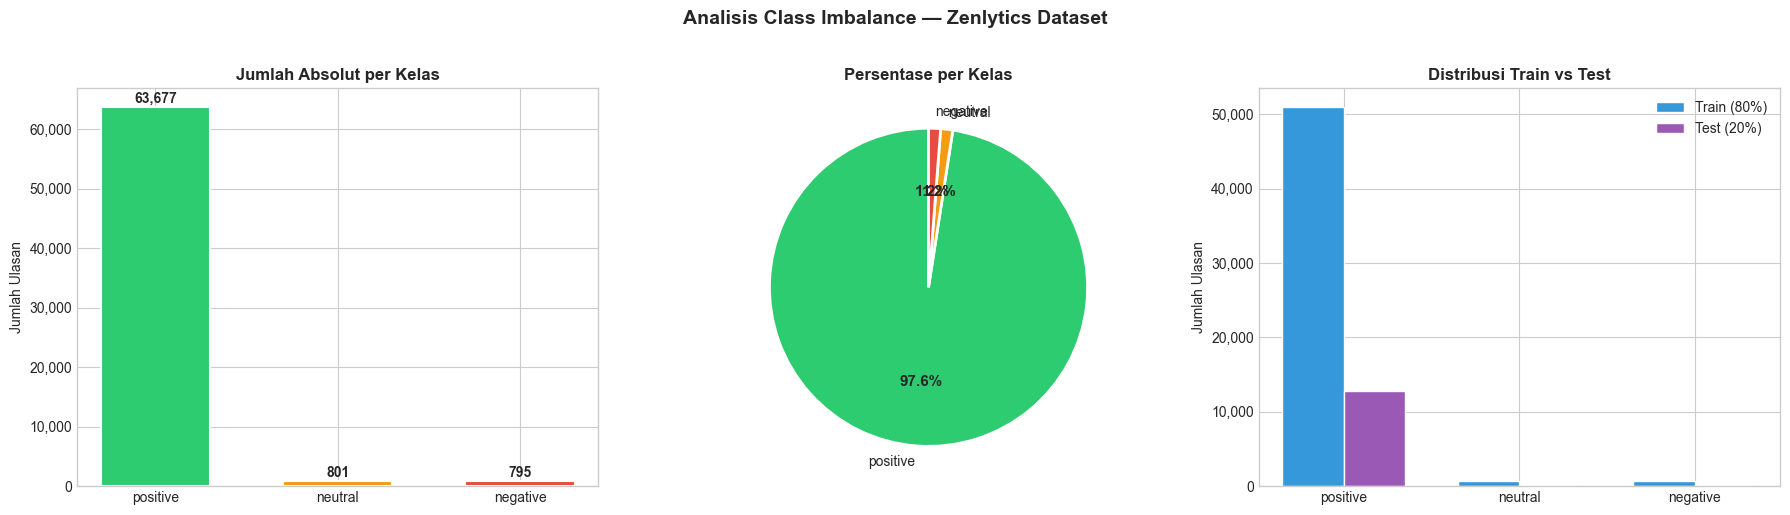

In [8]:
# ============================================================
# TAHAP 3B — Visualisasi Class Imbalance
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Analisis Class Imbalance — Zenlytics Dataset', fontsize=14, fontweight='bold', y=1.02)

# --- Plot 1: Bar chart jumlah absolut ---
counts = [distribusi[l] for l in urutan]
colors = [PALETTE[l] for l in urutan]
bars   = axes[0].bar(urutan, counts, color=colors, edgecolor='white', linewidth=1.5, width=0.6)
axes[0].set_title('Jumlah Absolut per Kelas', fontweight='bold')
axes[0].set_ylabel('Jumlah Ulasan')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))
# Tambahkan label angka di atas setiap bar
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 300,
                 f'{count:,}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# --- Plot 2: Pie chart persentase ---
pcts  = [distribusi[l] / total * 100 for l in urutan]
wedges, texts, autotexts = axes[1].pie(
    pcts, labels=urutan, colors=colors, autopct='%1.1f%%',
    startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
# Perbesar font label
for text in autotexts:
    text.set_fontsize(11)
    text.set_fontweight('bold')
axes[1].set_title('Persentase per Kelas', fontweight='bold')

# --- Plot 3: Bar chart distribusi di train vs test ---
x      = np.arange(len(urutan))
width  = 0.35
train_counts = [df_train['sentiment_label'].value_counts().get(l, 0) for l in urutan]
test_counts  = [df_test['sentiment_label'].value_counts().get(l, 0) for l in urutan]
axes[2].bar(x - width/2, train_counts, width, label='Train (80%)', color='#3498db', edgecolor='white')
axes[2].bar(x + width/2, test_counts,  width, label='Test (20%)',  color='#9b59b6', edgecolor='white')
axes[2].set_xticks(x)
axes[2].set_xticklabels(urutan)
axes[2].set_title('Distribusi Train vs Test', fontweight='bold')
axes[2].set_ylabel('Jumlah Ulasan')
axes[2].legend()
axes[2].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()

# Simpan grafik ke folder reports
save_path = os.path.join(REPORT_DIR, 'eda_01_class_imbalance.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'✅ Grafik disimpan: {save_path}')
plt.show()

---
## 📊 TAHAP 4 — Distribusi Fitur Numerik

**Mengapa perlu dianalisis?**  
Fitur numerik seperti `review_length_char`, `review_word_count`, dan `log_sold_count`  
akan digunakan sebagai **fitur tambahan** di samping teks. Kita perlu tahu:
- Apakah distribusinya normal atau skewed (miring)?
- Apakah ada perbedaan distribusi antar kelas sentimen?
- Apakah ada outlier ekstrem?

**Analogi:** Sebelum memasak, kita cek apakah bahan-bahan berukuran seragam.  
Kalau ada satu bahan yang 1000× lebih besar dari yang lain, kita perlu potong lebih kecil.

✅ Grafik disimpan: d:\capstone-project-pijak\reports\eda_02_distribusi_panjang_teks.png


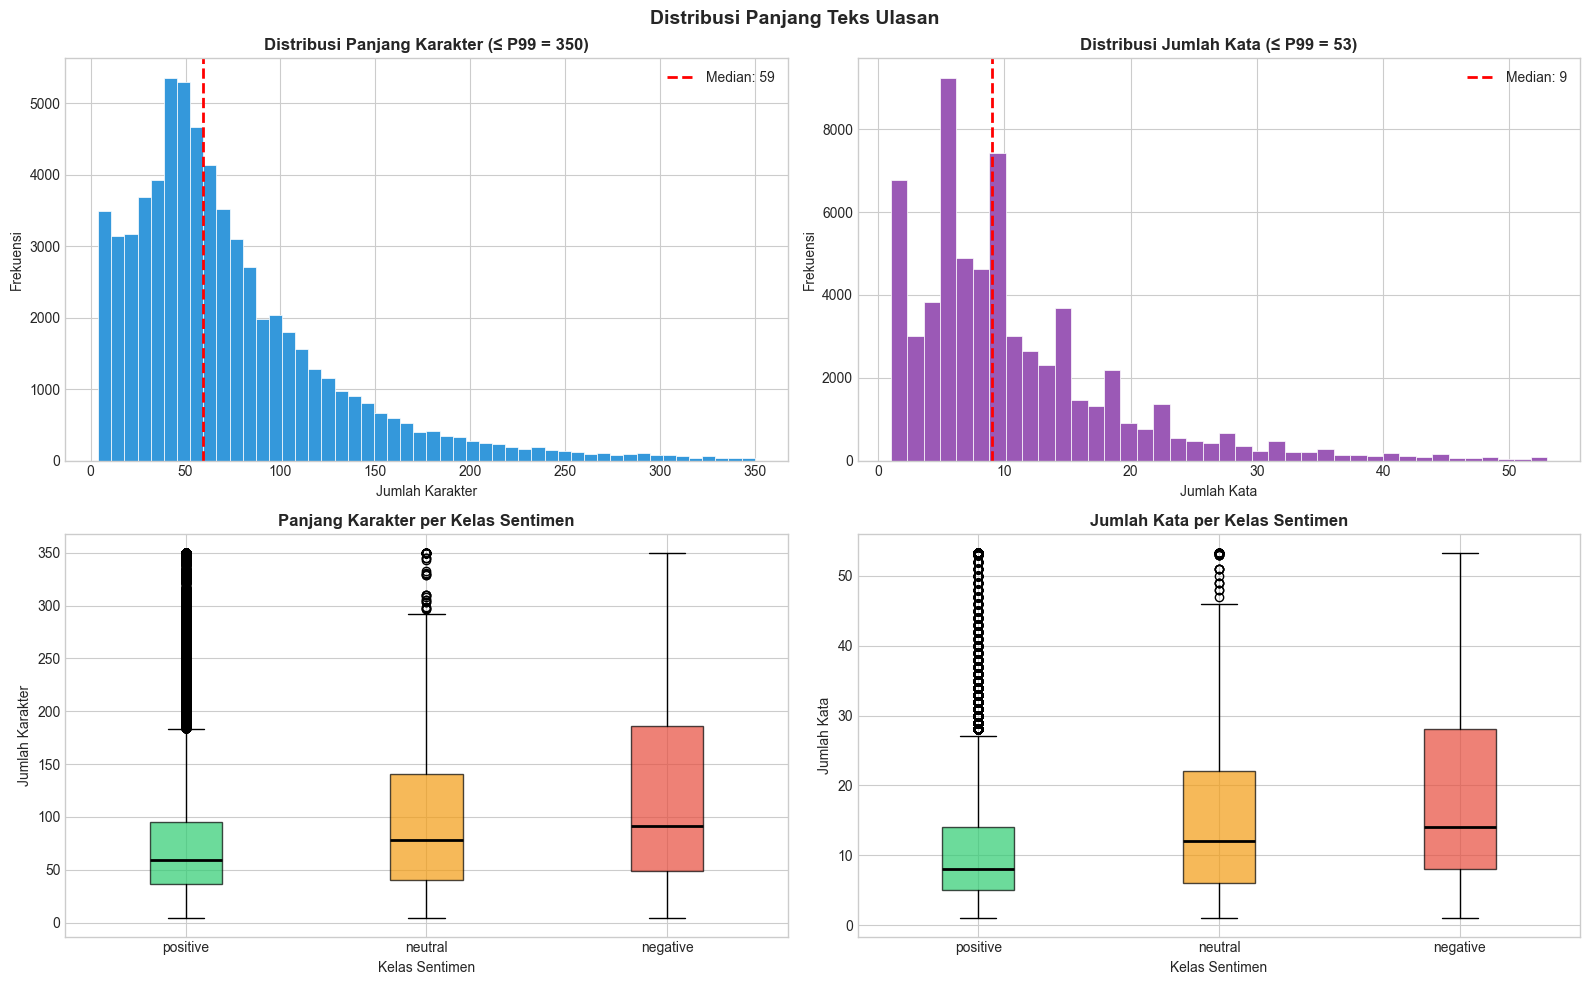


📊 Statistik Panjang Karakter per Kelas:


,count,mean,std,min,25%,50%,75%,max
sentiment_label,,,,,,,,
negative,795.00,144.50,158.91,4.00,49.00,91.00,186.00,"1,655.00"
neutral,801.00,110.57,108.16,4.00,40.00,78.00,141.00,823.00
positive,"63,677.00",77.61,174.98,4.00,36.00,59.00,95.00,"32,857.00"



📊 Statistik Jumlah Kata per Kelas:


,count,mean,std,min,25%,50%,75%,max
sentiment_label,,,,,,,,
negative,795.00,22.54,24.91,1.00,8.00,14.00,28.00,253.00
neutral,801.00,17.33,16.93,1.00,6.00,12.00,22.00,129.00
positive,"63,677.00",11.39,27.04,1.00,5.00,8.00,14.00,"5,665.00"


In [9]:
# ============================================================
# TAHAP 4A — Distribusi Review Length & Word Count
# Kita cek distribusi KESELURUHAN terlebih dahulu
# Kemudian per kelas sentimen (apa ada perbedaan?)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Distribusi Panjang Teks Ulasan', fontsize=14, fontweight='bold')

# --- 4A-1: Histogram review_length_char keseluruhan ---
# Kita batasi sampai persentil ke-99 agar 1% outlier ekstrem tidak mendistorsi grafik
cap_char = df['review_length_char'].quantile(0.99)
df_capped = df[df['review_length_char'] <= cap_char]
axes[0, 0].hist(df_capped['review_length_char'], bins=50, color='#3498db', edgecolor='white', linewidth=0.5)
axes[0, 0].set_title(f'Distribusi Panjang Karakter (≤ P99 = {int(cap_char):,})', fontweight='bold')
axes[0, 0].set_xlabel('Jumlah Karakter')
axes[0, 0].set_ylabel('Frekuensi')
axes[0, 0].axvline(df['review_length_char'].median(), color='red', linestyle='--',
                   linewidth=2, label=f'Median: {df["review_length_char"].median():.0f}')
axes[0, 0].legend()

# --- 4A-2: Histogram review_word_count keseluruhan ---
cap_word = df['review_word_count'].quantile(0.99)
df_capped2 = df[df['review_word_count'] <= cap_word]
axes[0, 1].hist(df_capped2['review_word_count'], bins=40, color='#9b59b6', edgecolor='white', linewidth=0.5)
axes[0, 1].set_title(f'Distribusi Jumlah Kata (≤ P99 = {int(cap_word):,})', fontweight='bold')
axes[0, 1].set_xlabel('Jumlah Kata')
axes[0, 1].set_ylabel('Frekuensi')
axes[0, 1].axvline(df['review_word_count'].median(), color='red', linestyle='--',
                   linewidth=2, label=f'Median: {df["review_word_count"].median():.0f}')
axes[0, 1].legend()

# --- 4A-3: Boxplot review_length_char PER KELAS SENTIMEN ---
# Ini menjawab: apakah ulasan negatif cenderung lebih panjang/pendek?
data_per_kelas_char = [df[df['sentiment_label'] == l]['review_length_char'].clip(upper=cap_char) for l in urutan]
bp = axes[1, 0].boxplot(data_per_kelas_char, labels=urutan, patch_artist=True,
                         medianprops={'color': 'black', 'linewidth': 2})
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 0].set_title('Panjang Karakter per Kelas Sentimen', fontweight='bold')
axes[1, 0].set_xlabel('Kelas Sentimen')
axes[1, 0].set_ylabel('Jumlah Karakter')

# --- 4A-4: Boxplot review_word_count PER KELAS SENTIMEN ---
data_per_kelas_word = [df[df['sentiment_label'] == l]['review_word_count'].clip(upper=cap_word) for l in urutan]
bp2 = axes[1, 1].boxplot(data_per_kelas_word, labels=urutan, patch_artist=True,
                          medianprops={'color': 'black', 'linewidth': 2})
for patch, color in zip(bp2['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 1].set_title('Jumlah Kata per Kelas Sentimen', fontweight='bold')
axes[1, 1].set_xlabel('Kelas Sentimen')
axes[1, 1].set_ylabel('Jumlah Kata')

plt.tight_layout()
save_path = os.path.join(REPORT_DIR, 'eda_02_distribusi_panjang_teks.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'✅ Grafik disimpan: {save_path}')
plt.show()

# Ringkasan statistik per kelas
print('\n📊 Statistik Panjang Karakter per Kelas:')
display(df.groupby('sentiment_label')['review_length_char'].describe())
print('\n📊 Statistik Jumlah Kata per Kelas:')
display(df.groupby('sentiment_label')['review_word_count'].describe())

✅ Grafik disimpan: d:\capstone-project-pijak\reports\eda_03_rating_dan_sold.png


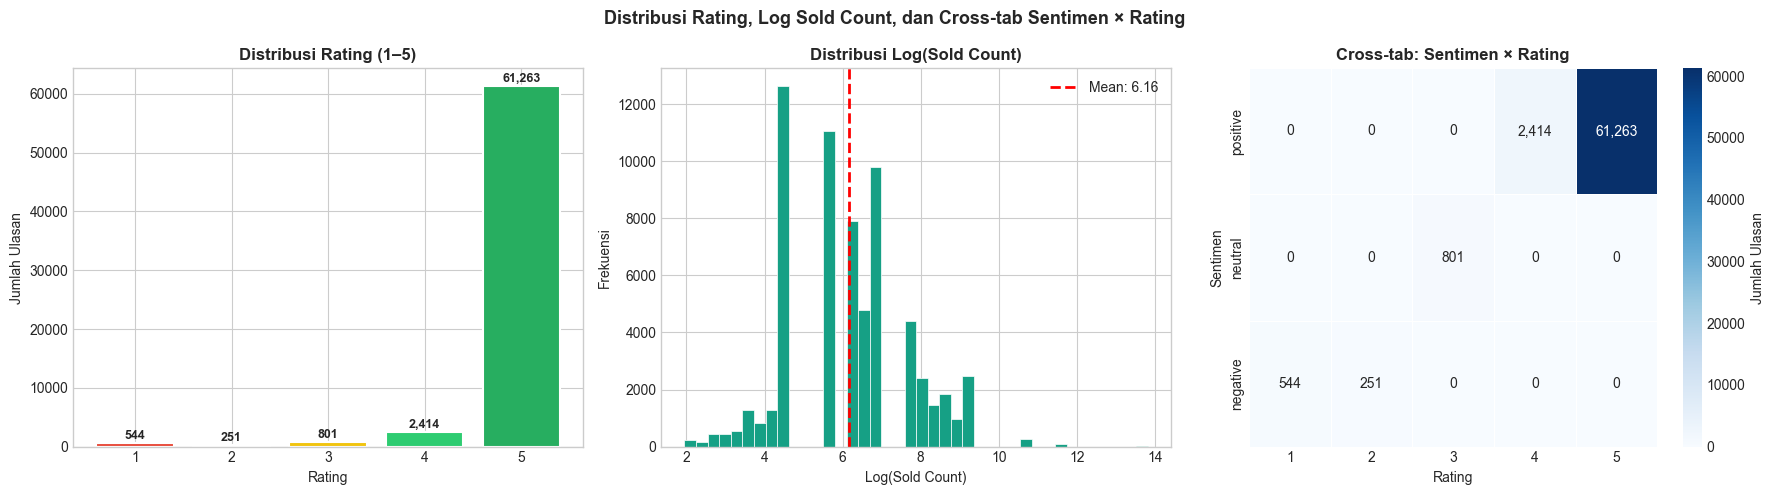


📊 Cross-tab Sentimen × Rating:


rating,1,2,3,4,5
sentiment_label,,,,,
positive,0,0,0,2414,61263
neutral,0,0,801,0,0
negative,544,251,0,0,0


In [10]:
# ============================================================
# TAHAP 4B — Distribusi Rating & Log Sold Count
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribusi Rating, Log Sold Count, dan Cross-tab Sentimen × Rating',
             fontsize=13, fontweight='bold')

# --- Plot 1: Rating distribution ---
rating_counts = df['rating'].value_counts().sort_index()
bar_colors    = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
bars = axes[0].bar(rating_counts.index.astype(str), rating_counts.values,
                   color=bar_colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribusi Rating (1–5)', fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Jumlah Ulasan')
for bar, val in zip(bars, rating_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
                 f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# --- Plot 2: Log sold count distribution ---
axes[1].hist(df['log_sold_count'], bins=40, color='#16a085', edgecolor='white', linewidth=0.5)
axes[1].set_title('Distribusi Log(Sold Count)', fontweight='bold')
axes[1].set_xlabel('Log(Sold Count)')
axes[1].set_ylabel('Frekuensi')
axes[1].axvline(df['log_sold_count'].mean(), color='red', linestyle='--',
                linewidth=2, label=f'Mean: {df["log_sold_count"].mean():.2f}')
axes[1].legend()

# --- Plot 3: Cross-tab Sentimen vs Rating (heatmap) ---
# Cross-tab = tabel silang, seperti pivot table di Excel
ct = pd.crosstab(df['sentiment_label'], df['rating'])
ct = ct.reindex(urutan)  # urutkan: positive, neutral, negative
sns.heatmap(ct, annot=True, fmt=',d', cmap='Blues', ax=axes[2],
            linewidths=0.5, cbar_kws={'label': 'Jumlah Ulasan'})
axes[2].set_title('Cross-tab: Sentimen × Rating', fontweight='bold')
axes[2].set_xlabel('Rating')
axes[2].set_ylabel('Sentimen')

plt.tight_layout()
save_path = os.path.join(REPORT_DIR, 'eda_03_rating_dan_sold.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'✅ Grafik disimpan: {save_path}')
plt.show()

print('\n📊 Cross-tab Sentimen × Rating:')
display(ct)

---
## 💬 TAHAP 5 — Analisis Teks (NLP Insight)

**Mengapa perlu?**  
Ini adalah inti dari proyek NLP kita. Kita perlu tahu:
- Kata-kata apa yang **paling sering muncul** di masing-masing kelas?
- Apakah ada kata yang **dominan di satu kelas** tapi jarang di kelas lain?

**Analogi:** Seperti membaca ratusan surat komplain pelanggan — kita cari kata-kata yang  
paling sering muncul agar bisa memahami pola keluhan secara cepat.

Insight ini berguna untuk **memvalidasi** bahwa preprocessing (stemming, stopword removal)  
sudah bekerja dengan benar, dan kata-kata yang tersisa memang bermakna.

✅ Grafik disimpan: d:\capstone-project-pijak\reports\eda_04_top_kata_per_kelas.png


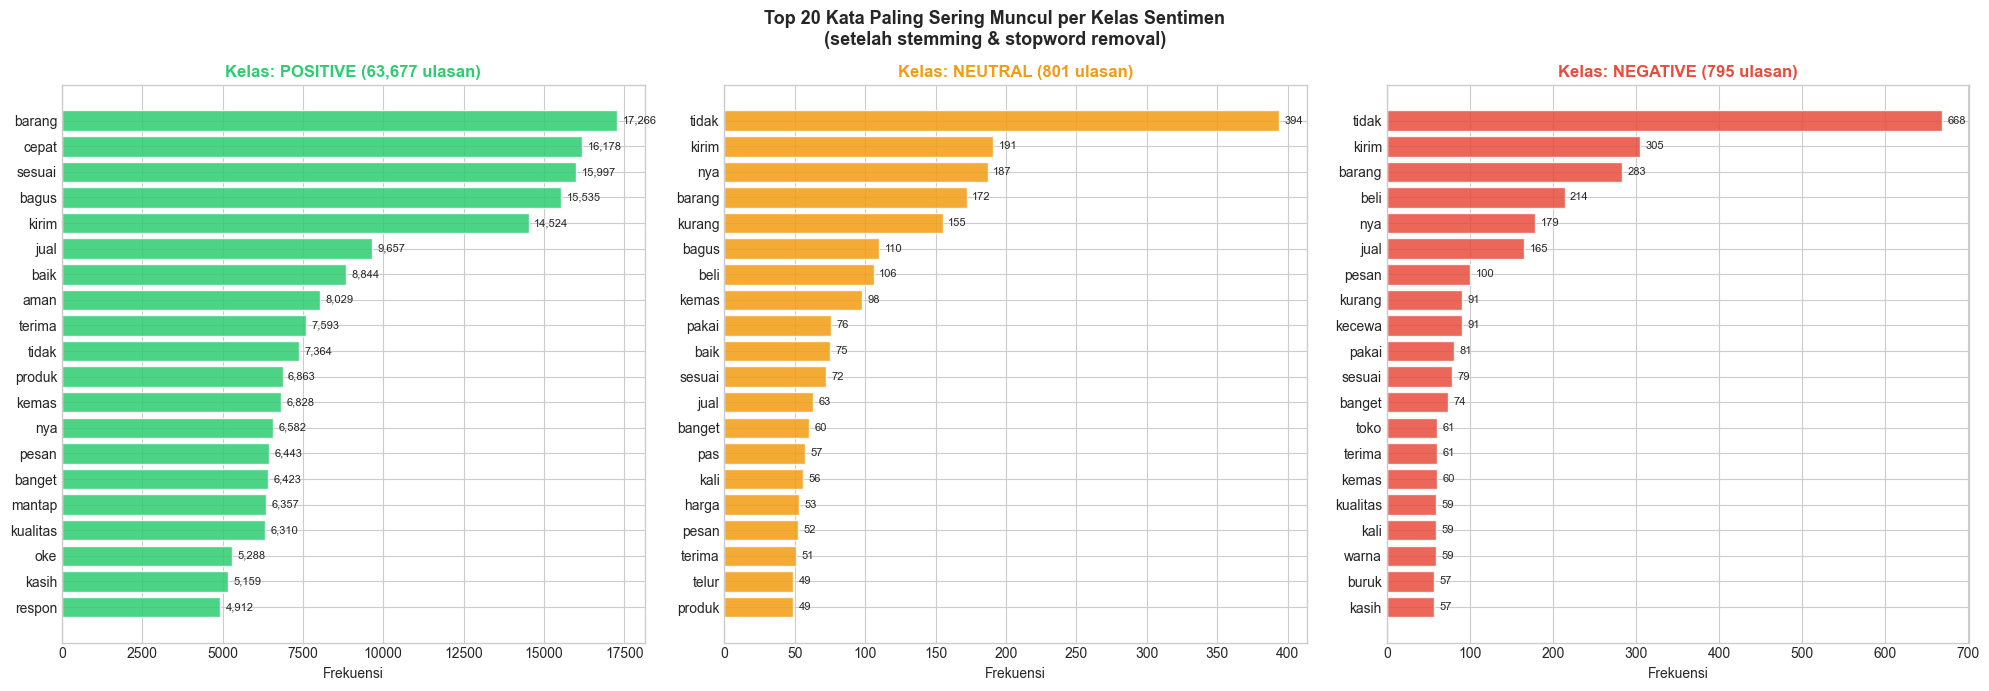

In [11]:
# ============================================================
# TAHAP 5A — Top 20 Kata per Kelas Sentimen
# ============================================================

def get_top_words(dataframe, label, n=20):
    """
    Fungsi untuk mendapatkan N kata teratas dari kelas tertentu.
    
    Parameter:
    - dataframe : DataFrame yang berisi data
    - label     : kelas sentimen ('positive', 'neutral', 'negative')
    - n         : jumlah kata teratas yang ingin ditampilkan
    
    Return: list of tuples [(kata, frekuensi), ...]
    """
    # Filter hanya baris dengan label tersebut
    teks_gabungan = dataframe[dataframe['sentiment_label'] == label]['review_text_stemmed']
    
    # Hilangkan baris null (13 baris yang flagged oleh DE)
    teks_gabungan = teks_gabungan.dropna()
    
    # Gabungkan semua teks menjadi satu string panjang
    # Lalu split per kata dan hitung frekuensinya
    semua_kata = ' '.join(teks_gabungan).split()
    return Counter(semua_kata).most_common(n)


fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Top 20 Kata Paling Sering Muncul per Kelas Sentimen\n(setelah stemming & stopword removal)',
             fontsize=13, fontweight='bold')

for i, label in enumerate(urutan):
    top_words = get_top_words(df, label, n=20)
    
    if not top_words:
        axes[i].text(0.5, 0.5, 'Tidak ada data', ha='center', va='center')
        continue
    
    kata_list  = [w for w, _ in top_words]
    freq_list  = [f for _, f in top_words]
    
    # Horizontal bar chart — lebih mudah dibaca untuk label panjang
    y_pos = range(len(kata_list))
    bars  = axes[i].barh(y_pos, freq_list, color=PALETTE[label], alpha=0.85, edgecolor='white')
    axes[i].set_yticks(y_pos)
    axes[i].set_yticklabels(kata_list, fontsize=10)
    axes[i].invert_yaxis()  # kata dengan frekuensi tertinggi di atas
    axes[i].set_title(f'Kelas: {label.upper()} ({distribusi[label]:,} ulasan)', fontweight='bold',
                      color=PALETTE[label])
    axes[i].set_xlabel('Frekuensi')
    
    # Tambahkan label angka di samping bar
    for bar, freq in zip(bars, freq_list):
        axes[i].text(bar.get_width() + max(freq_list) * 0.01, bar.get_y() + bar.get_height() / 2,
                     f'{freq:,}', va='center', fontsize=8)

plt.tight_layout()
save_path = os.path.join(REPORT_DIR, 'eda_04_top_kata_per_kelas.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'✅ Grafik disimpan: {save_path}')
plt.show()

✅ Grafik disimpan: d:\capstone-project-pijak\reports\eda_05_wordcloud.png


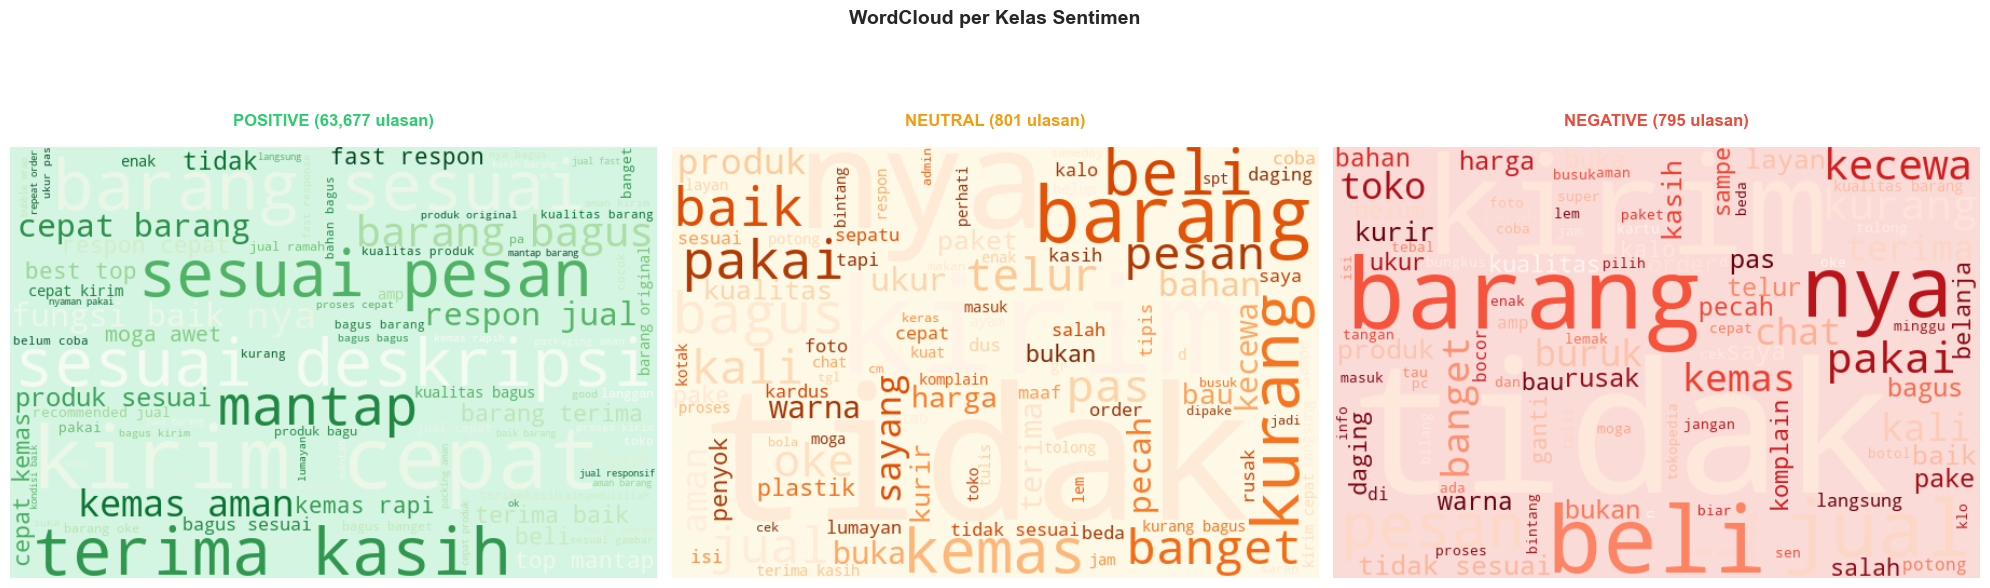

In [12]:
# ============================================================
# TAHAP 5B — WordCloud per Kelas Sentimen
# ============================================================
# WordCloud = visualisasi teks di mana ukuran kata menunjukkan frekuensinya
# Kata yang lebih sering muncul akan tampil lebih besar

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('WordCloud per Kelas Sentimen', fontsize=14, fontweight='bold')

# Warna background per kelas
bg_colors = {'positive': '#d5f5e3', 'neutral': '#fef9e7', 'negative': '#fadbd8'}

for i, label in enumerate(urutan):
    teks_kelas = df[df['sentiment_label'] == label]['review_text_stemmed'].dropna()
    teks_gabung = ' '.join(teks_kelas)
    
    if not teks_gabung.strip():
        axes[i].text(0.5, 0.5, 'Tidak ada data', ha='center', va='center')
        continue
    
    # Buat WordCloud
    wc = WordCloud(
        width=600, height=400,
        background_color=bg_colors[label],
        colormap='Greens' if label == 'positive' else ('Oranges' if label == 'neutral' else 'Reds'),
        max_words=100,
        min_font_size=8,
        prefer_horizontal=0.9,
        random_state=42
    ).generate(teks_gabung)
    
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(f'{label.upper()} ({distribusi[label]:,} ulasan)',
                      fontweight='bold', fontsize=12, color=PALETTE[label],
                      pad=15)

plt.tight_layout()
save_path = os.path.join(REPORT_DIR, 'eda_05_wordcloud.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'✅ Grafik disimpan: {save_path}')
plt.show()

---
## 🏷️ TAHAP 6 — Analisis Fitur Kategorikal

**Mengapa perlu?**  
Fitur seperti `product_category` dan `price_category_encoded` bisa jadi sinyal penting:  
- Apakah produk dari kategori tertentu cenderung dapat lebih banyak ulasan negatif?  
- Apakah produk murah vs mahal memiliki pola sentimen berbeda?

Jawaban dari pertanyaan ini bisa memperkuat model atau menjadi insight bisnis yang berharga.

✅ Grafik disimpan: d:\capstone-project-pijak\reports\eda_06_kategori_produk.png


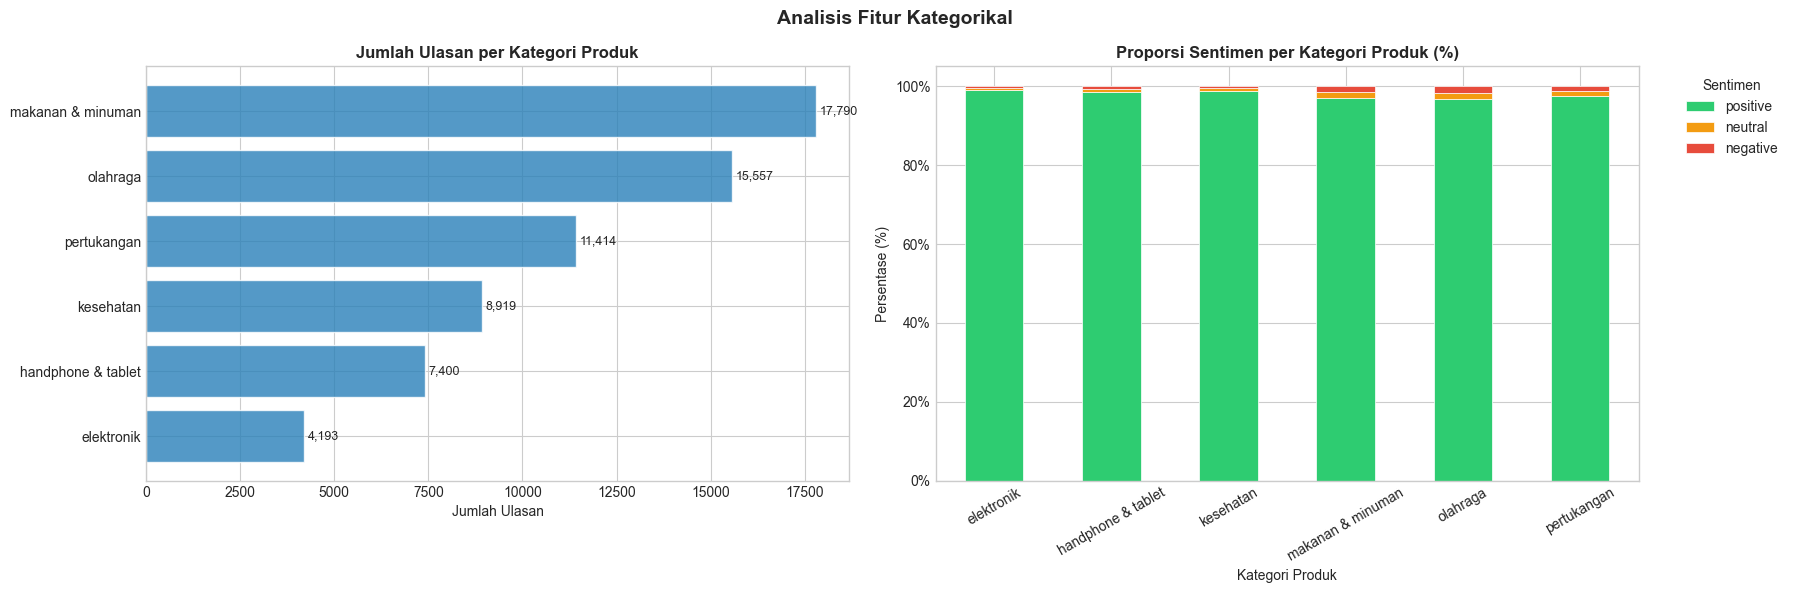


📊 Proporsi Sentimen per Kategori (%):


sentiment_label,positive,neutral,negative
product_category,,,
elektronik,98.93,0.50,0.57
handphone & tablet,98.49,0.68,0.84
kesehatan,98.85,0.72,0.44
makanan & minuman,96.89,1.64,1.47
olahraga,96.77,1.47,1.77
pertukangan,97.55,1.29,1.17


In [13]:
# ============================================================
# TAHAP 6A — Distribusi Kategori Produk
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Analisis Fitur Kategorikal', fontsize=14, fontweight='bold')

# --- Plot 1: Distribusi Kategori Produk (total) ---
cat_counts = df['product_category'].value_counts()
y_pos = range(len(cat_counts))
axes[0].barh(y_pos, cat_counts.values, color='#2980b9', alpha=0.8, edgecolor='white')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(cat_counts.index, fontsize=10)
axes[0].invert_yaxis()
axes[0].set_title('Jumlah Ulasan per Kategori Produk', fontweight='bold')
axes[0].set_xlabel('Jumlah Ulasan')
for j, (val, y) in enumerate(zip(cat_counts.values, y_pos)):
    axes[0].text(val + 100, y, f'{val:,}', va='center', fontsize=9)

# --- Plot 2: Stacked bar — Sentimen per Kategori Produk ---
# Stacked bar = bar bertumpuk, memperlihatkan proporsi per segmen
ct_cat = pd.crosstab(df['product_category'], df['sentiment_label'], normalize='index') * 100
ct_cat = ct_cat.reindex(columns=urutan, fill_value=0)
ct_cat.plot(
    kind='bar', stacked=True, ax=axes[1],
    color=[PALETTE[l] for l in urutan],
    edgecolor='white', linewidth=0.5
)
axes[1].set_title('Proporsi Sentimen per Kategori Produk (%)', fontweight='bold')
axes[1].set_xlabel('Kategori Produk')
axes[1].set_ylabel('Persentase (%)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Sentimen', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.tight_layout()
save_path = os.path.join(REPORT_DIR, 'eda_06_kategori_produk.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'✅ Grafik disimpan: {save_path}')
plt.show()

print('\n📊 Proporsi Sentimen per Kategori (%):')
display(ct_cat.round(2))

✅ Grafik disimpan: d:\capstone-project-pijak\reports\eda_07_kategori_harga.png


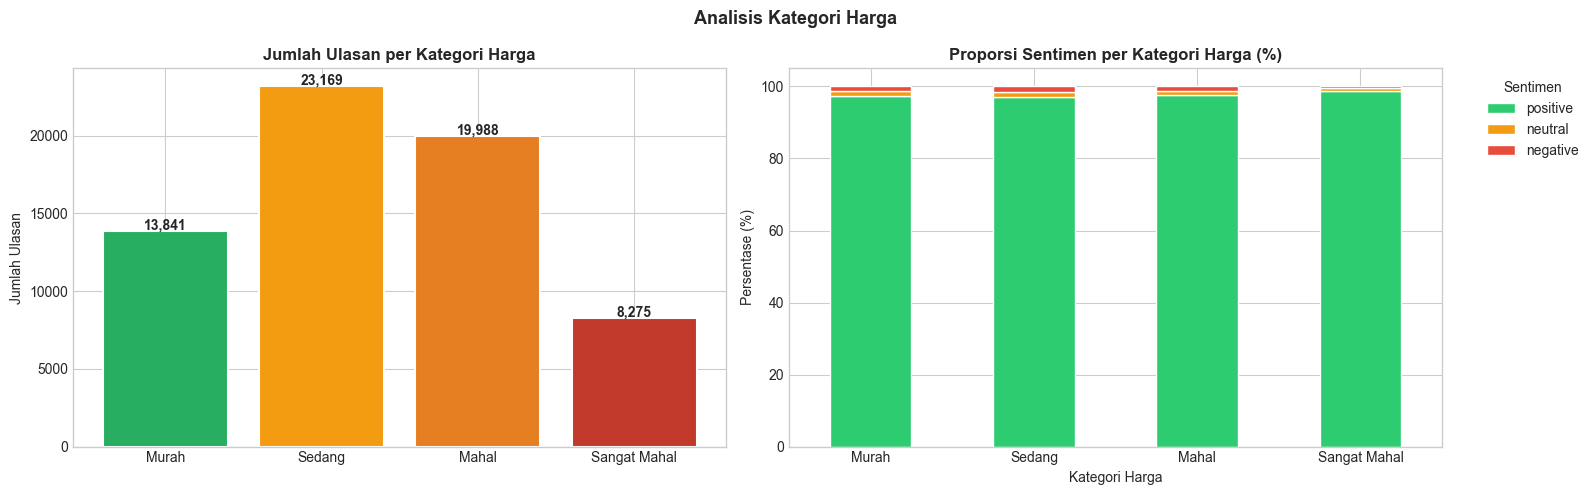

In [14]:
# ============================================================
# TAHAP 6B — Distribusi Price Category
# ============================================================
# Mapping encoding dari pipeline DE:
# 0 = Murah, 1 = Sedang, 2 = Mahal, 3 = Sangat Mahal
# (sesuaikan jika encoding berbeda di pipeline DE)

PRICE_MAP = {0: 'Murah', 1: 'Sedang', 2: 'Mahal', 3: 'Sangat Mahal'}
df['price_category_label'] = df['price_category_encoded'].map(PRICE_MAP)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Analisis Kategori Harga', fontsize=13, fontweight='bold')

# Plot 1: Jumlah ulasan per kategori harga
price_counts = df['price_category_label'].value_counts().reindex(['Murah', 'Sedang', 'Mahal', 'Sangat Mahal'])
axes[0].bar(price_counts.index, price_counts.values,
            color=['#27ae60', '#f39c12', '#e67e22', '#c0392b'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Jumlah Ulasan per Kategori Harga', fontweight='bold')
axes[0].set_ylabel('Jumlah Ulasan')
for i, (idx, val) in enumerate(price_counts.items()):
    axes[0].text(i, val + 100, f'{val:,}', ha='center', fontweight='bold', fontsize=10)

# Plot 2: Proporsi sentimen per kategori harga
ct_price = pd.crosstab(df['price_category_label'], df['sentiment_label'], normalize='index') * 100
ct_price = ct_price.reindex(index=['Murah', 'Sedang', 'Mahal', 'Sangat Mahal'],
                             columns=urutan, fill_value=0)
ct_price.plot(
    kind='bar', stacked=True, ax=axes[1],
    color=[PALETTE[l] for l in urutan],
    edgecolor='white'
)
axes[1].set_title('Proporsi Sentimen per Kategori Harga (%)', fontweight='bold')
axes[1].set_xlabel('Kategori Harga')
axes[1].set_ylabel('Persentase (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Sentimen', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
save_path = os.path.join(REPORT_DIR, 'eda_07_kategori_harga.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'✅ Grafik disimpan: {save_path}')
plt.show()

---
## 📅 TAHAP 7 — Analisis Temporal

**Mengapa perlu?**  
Pola waktu bisa menyimpan sinyal penting:
- Apakah ulasan negatif meningkat di bulan/tahun tertentu?
- Apakah ada tren peningkatan kualitas produk dari tahun ke tahun?

Ini juga membantu memutuskan apakah fitur `review_year` dan `review_month`  
layak dimasukkan ke model atau tidak.

✅ Grafik disimpan: d:\capstone-project-pijak\reports\eda_08_analisis_temporal.png


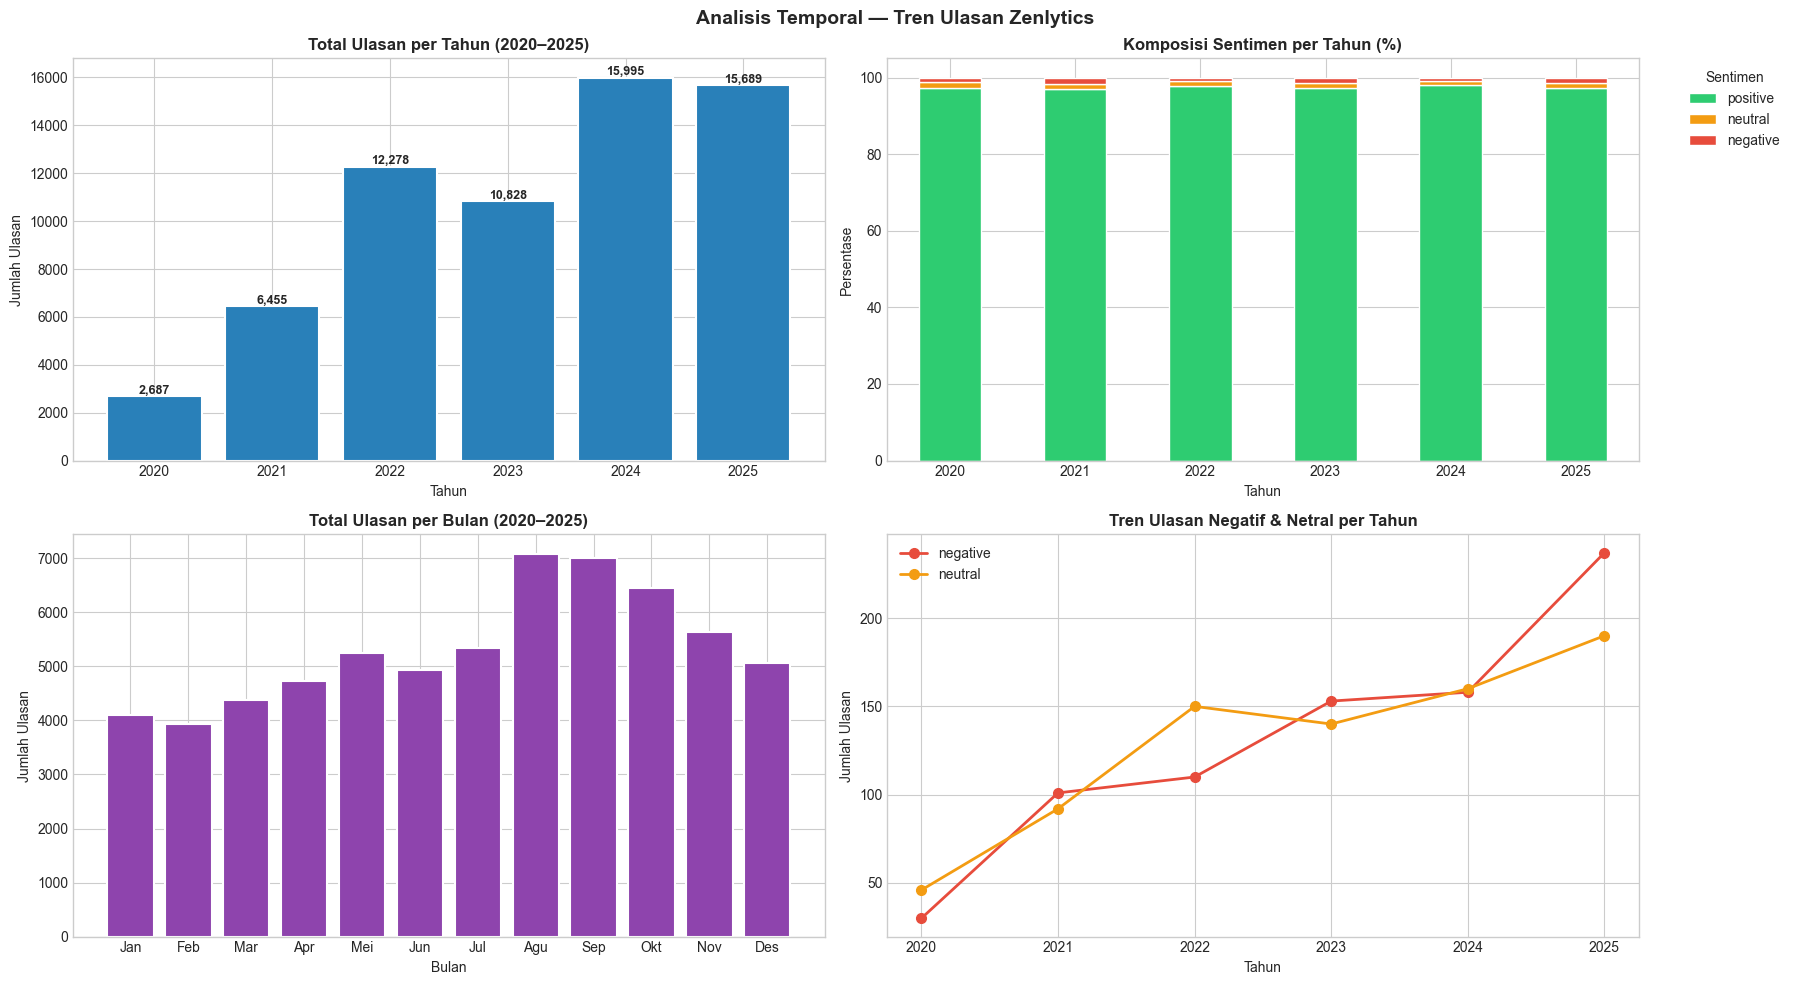

In [15]:
# ============================================================
# TAHAP 7A — Tren Ulasan per Tahun
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Analisis Temporal — Tren Ulasan Zenlytics', fontsize=14, fontweight='bold')

# Fokus ke tahun 2020–2025 (data sebelumnya sangat sedikit / anomali)
df_modern = df[df['review_year'] >= 2020].copy()

# --- Plot 1: Total ulasan per tahun ---
tahun_total = df_modern['review_year'].value_counts().sort_index()
axes[0, 0].bar(tahun_total.index.astype(str), tahun_total.values,
               color='#2980b9', edgecolor='white', linewidth=1.5)
axes[0, 0].set_title('Total Ulasan per Tahun (2020–2025)', fontweight='bold')
axes[0, 0].set_xlabel('Tahun')
axes[0, 0].set_ylabel('Jumlah Ulasan')
for i, (idx, val) in enumerate(tahun_total.items()):
    axes[0, 0].text(i, val + 100, f'{val:,}', ha='center', fontsize=9, fontweight='bold')

# --- Plot 2: Komposisi sentimen per tahun (stacked bar) ---
ct_tahun = pd.crosstab(df_modern['review_year'], df_modern['sentiment_label'], normalize='index') * 100
ct_tahun = ct_tahun.reindex(columns=urutan, fill_value=0)
ct_tahun.plot(
    kind='bar', stacked=True, ax=axes[0, 1],
    color=[PALETTE[l] for l in urutan],
    edgecolor='white'
)
axes[0, 1].set_title('Komposisi Sentimen per Tahun (%)', fontweight='bold')
axes[0, 1].set_xlabel('Tahun')
axes[0, 1].set_ylabel('Persentase')
axes[0, 1].tick_params(axis='x', rotation=0)
axes[0, 1].legend(title='Sentimen', bbox_to_anchor=(1.05, 1), loc='upper left')

# --- Plot 3: Distribusi ulasan per bulan ---
bulan_total = df_modern['review_month'].value_counts().sort_index()
nama_bulan  = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun',
               'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des']
bulan_labels = [nama_bulan[m-1] for m in bulan_total.index]
axes[1, 0].bar(bulan_labels, bulan_total.values, color='#8e44ad', edgecolor='white', linewidth=1.5)
axes[1, 0].set_title('Total Ulasan per Bulan (2020–2025)', fontweight='bold')
axes[1, 0].set_xlabel('Bulan')
axes[1, 0].set_ylabel('Jumlah Ulasan')

# --- Plot 4: Line chart tren sentimen negatif + netral per tahun ---
# Fokus ke kelas minoritas — ini yang paling kritis untuk dimonitor
ct_tahun_abs = pd.crosstab(df_modern['review_year'], df_modern['sentiment_label'])
for label in ['negative', 'neutral']:
    if label in ct_tahun_abs.columns:
        axes[1, 1].plot(ct_tahun_abs.index, ct_tahun_abs[label],
                        marker='o', linewidth=2, markersize=7,
                        color=PALETTE[label], label=label)
axes[1, 1].set_title('Tren Ulasan Negatif & Netral per Tahun', fontweight='bold')
axes[1, 1].set_xlabel('Tahun')
axes[1, 1].set_ylabel('Jumlah Ulasan')
axes[1, 1].legend()
axes[1, 1].set_xticks(ct_tahun_abs.index)

plt.tight_layout()
save_path = os.path.join(REPORT_DIR, 'eda_08_analisis_temporal.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'✅ Grafik disimpan: {save_path}')
plt.show()

---
## 🔗 TAHAP 8 — Korelasi Fitur Numerik

**Mengapa perlu?**  
Korelasi tinggi antara dua fitur = informasi redundan = model bisa bingung.  

**Analogi:** Bayangkan kamu diminta menjelaskan nilai ujian seseorang,  
dan kamu pakai dua variabel: 'jam belajar' dan 'menit belajar'.  
Keduanya mengukur hal yang sama — salah satu tidak perlu dimasukkan.

**Acuan:** Korelasi > 0.8 atau < -0.8 → pertimbangkan untuk menghapus salah satunya.

✅ Grafik disimpan: d:\capstone-project-pijak\reports\eda_09_korelasi_fitur.png


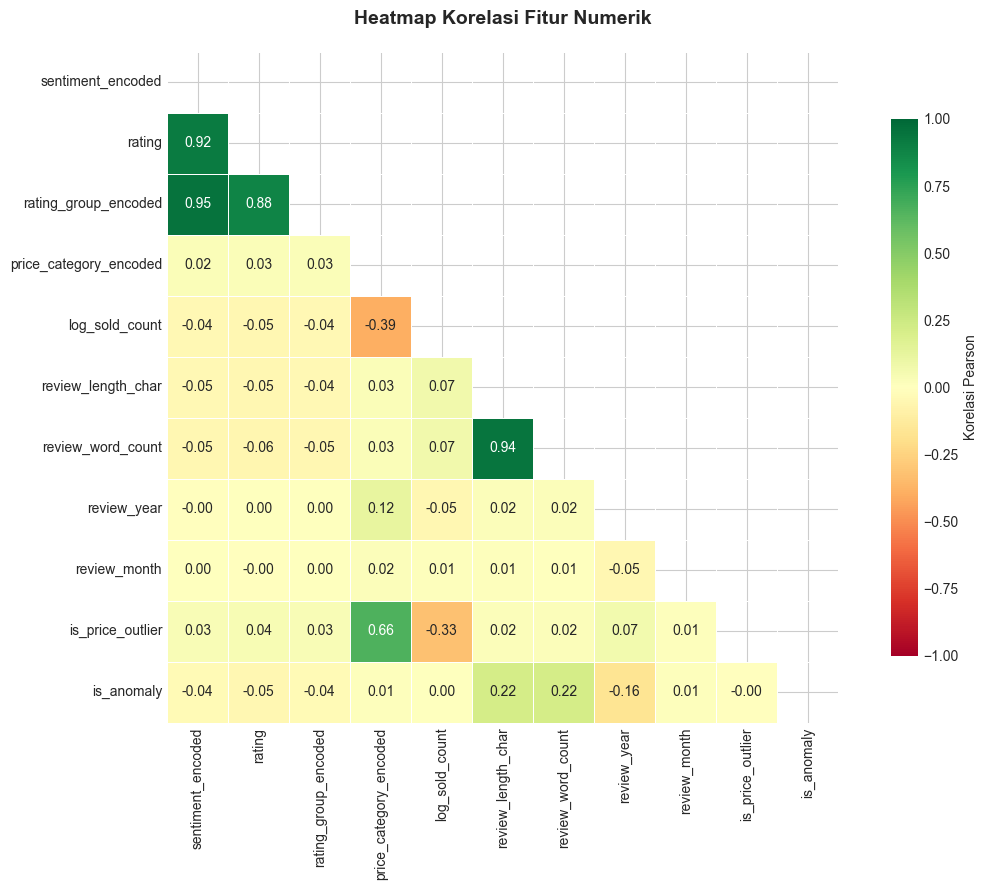


⚠️  Pasangan fitur dengan korelasi |r| > 0.5 (perlu diperhatikan):
--------------------------------------------------
  rating                    × sentiment_encoded         | r = 0.917
  rating_group_encoded      × sentiment_encoded         | r = 0.947
  rating_group_encoded      × rating                    | r = 0.878
  review_word_count         × review_length_char        | r = 0.938
  is_price_outlier          × price_category_encoded    | r = 0.662


In [16]:
# ============================================================
# TAHAP 8 — HEATMAP KORELASI
# ============================================================
# .corr() → menghitung korelasi Pearson antar kolom numerik
# Nilai: -1 (korelasi negatif sempurna) → 0 (tidak ada) → +1 (korelasi positif sempurna)

FITUR_KORELASI = [
    'sentiment_encoded',
    'rating',
    'rating_group_encoded',
    'price_category_encoded',
    'log_sold_count',
    'review_length_char',
    'review_word_count',
    'review_year',
    'review_month',
    'is_price_outlier',
    'is_anomaly',
]

corr_matrix = df[FITUR_KORELASI].corr()

fig, ax = plt.subplots(figsize=(12, 9))

# Buat mask untuk segitiga atas (agar tidak redundan)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,         # tampilkan angka korelasi
    fmt='.2f',          # 2 angka desimal
    cmap='RdYlGn',      # merah = negatif, hijau = positif
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Korelasi Pearson', 'shrink': 0.8}
)

ax.set_title('Heatmap Korelasi Fitur Numerik', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()

save_path = os.path.join(REPORT_DIR, 'eda_09_korelasi_fitur.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'✅ Grafik disimpan: {save_path}')
plt.show()

# Tampilkan pasangan fitur dengan korelasi tinggi (|r| > 0.5)
print('\n⚠️  Pasangan fitur dengan korelasi |r| > 0.5 (perlu diperhatikan):')
print('-' * 50)
ditemukan = False
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.5:
            print(f'  {corr_matrix.columns[i]:25} × {corr_matrix.columns[j]:25} | r = {r:.3f}')
            ditemukan = True
if not ditemukan:
    print('  ✅ Tidak ada pasangan fitur dengan korelasi > 0.5')

---
## ✅ TAHAP 9 — Kesimpulan EDA & Rekomendasi Modeling

Ini adalah output **paling penting** dari notebook EDA — ringkasan temuan dan panduan  
konkret untuk membangun model di notebook berikutnya (`03_modeling.ipynb`).

In [17]:
# ============================================================
# TAHAP 9 — KESIMPULAN & REKOMENDASI MODELING
# ============================================================

print('=' * 65)
print('📝 KESIMPULAN EDA — Zenlytics Dataset')
print('=' * 65)

print('''
┌─────────────────────────────────────────────────────────────┐
│  TEMUAN 1 — CLASS IMBALANCE (KRITIS)                        │
├─────────────────────────────────────────────────────────────┤
│  Rasio: 80:1 (positive 97.6%, neutral 1.2%, negative 1.2%) │
│  → Ini adalah tantangan terbesar dalam project ini         │
│  → Accuracy TIDAK BISA dijadikan metrik utama              │
│  → Gunakan F1-Score MACRO sebagai metrik utama             │
└─────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────┐
│  TEMUAN 2 — DISTRIBUSI TEKS                                 │
├─────────────────────────────────────────────────────────────┤
│  Median panjang teks: ~59 karakter / ~9 kata               │
│  Distribusi sangat right-skewed (ekor panjang ke kanan)    │
│  Ulasan negatif cenderung lebih panjang dari positif       │
│  → 14 baris teks stemmed null — handle dengan fillna('')   │
└─────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────┐
│  TEMUAN 3 — KORELASI SENTIMEN × RATING                     │
├─────────────────────────────────────────────────────────────┤
│  Korelasi sempurna: negatif=rating 1-2, netral=3, positif=4-5│
│  → rating dan sentiment_encoded memiliki korelasi TINGGI   │
│  → Hati-hati: jika model terlalu bergantung pada rating    │
│     maka bukan NLP yang bekerja, tapi rating lookup        │
│  → Untuk model NLP murni: coba train TANPA fitur rating    │
└─────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────┐
│  TEMUAN 4 — FITUR KATEGORIKAL                               │
├─────────────────────────────────────────────────────────────┤
│  Kategori terbanyak: Makanan (17.8k), Olahraga (15.6k)    │
│  Proporsi sentimen hampir seragam across kategori          │
│  → product_category mungkin kurang informatif untuk model  │
│  → Bisa digunakan sebagai fitur tambahan saja              │
└─────────────────────────────────────────────────────────────┘
''')

print('=' * 65)
print('🚀 REKOMENDASI UNTUK 03_modeling.ipynb')
print('=' * 65)
print('''
LANGKAH 1 — HANDLE NULL TEKS (WAJIB DILAKUKAN PERTAMA)
   df['review_text_stemmed'] = df['review_text_stemmed'].fillna('')
   (13 baris null → isi dengan string kosong agar tidak error)

LANGKAH 2 — PILIH FITUR INPUT MODEL
   Fitur Teks Utama : review_text_stemmed
   Fitur Numerik    : review_length_char, review_word_count,
                      log_sold_count, price_category_encoded
   ⚠️  HINDARI      : rating & rating_group_encoded
                      (korelasi terlalu tinggi dengan target)

LANGKAH 3 — STRATEGI IMBALANCE (PILIH SALAH SATU ATAU KOMBINASI)
   A. class_weight='balanced' pada model sklearn
      → Cepat, tanpa mengubah data
      → Cocok untuk: LogisticRegression, SVM, RandomForest

   B. SMOTE (Synthetic Minority Oversampling Technique)
      from imblearn.over_sampling import SMOTE
      sm = SMOTE(random_state=42)
      X_resampled, y_resampled = sm.fit_resample(X_train, y_train)
      → Membuat data sintetis untuk kelas minoritas
      → Terapkan HANYA pada X_train (JANGAN pada X_test!)

   C. KOMBINASI: SMOTE + class_weight (paling kuat untuk rasio 80:1)

LANGKAH 4 — METRIK EVALUASI (WAJIB)
   from sklearn.metrics import classification_report, f1_score
   ✅ GUNAKAN  : F1-Score macro, Precision, Recall per kelas
   ✅ GUNAKAN  : Confusion Matrix
   ❌ JANGAN   : Accuracy saja (sangat menyesatkan di dataset ini)

LANGKAH 5 — BASELINE MODEL (mulai dari yang sederhana)
   1. TF-IDF + Logistic Regression (class_weight='balanced')
   2. TF-IDF + SVM (class_weight='balanced')
   3. TF-IDF + Random Forest
   4. (Opsional) SMOTE + salah satu dari atas
   5. (Advanced) IndoBERT / indobenchmark untuk deep learning

TARGET F1-SCORE:
   Minimum : F1-macro ≥ 0.60
   Baik    : F1-macro ≥ 0.70
   Optimal : F1-macro ≥ 0.75
''')

📝 KESIMPULAN EDA — Zenlytics Dataset

┌─────────────────────────────────────────────────────────────┐
│  TEMUAN 1 — CLASS IMBALANCE (KRITIS)                        │
├─────────────────────────────────────────────────────────────┤
│  Rasio: 80:1 (positive 97.6%, neutral 1.2%, negative 1.2%) │
│  → Ini adalah tantangan terbesar dalam project ini         │
│  → Accuracy TIDAK BISA dijadikan metrik utama              │
│  → Gunakan F1-Score MACRO sebagai metrik utama             │
└─────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────┐
│  TEMUAN 2 — DISTRIBUSI TEKS                                 │
├─────────────────────────────────────────────────────────────┤
│  Median panjang teks: ~59 karakter / ~9 kata               │
│  Distribusi sangat right-skewed (ekor panjang ke kanan)    │
│  Ulasan negatif cenderung lebih panjang dari positif       │
│  → 14 baris teks stemmed null — handle dengan fillna('')   │
└────────

In [18]:
# ============================================================
# SIMPAN RINGKASAN EDA KE FILE MARKDOWN
# (untuk dokumentasi capstone project)
# ============================================================

from datetime import datetime
timestamp = datetime.now().strftime('%Y%m%d_%H%M')

laporan = f"""# Laporan EDA — Zenlytics
**Tanggal:** {datetime.now().strftime('%d %B %Y, %H:%M')}  


## Ringkasan Dataset
- Total baris: {len(df):,}
- Total kolom: {df.shape[1]}
- Train set: {len(df_train):,} baris | Test set: {len(df_test):,} baris

## Distribusi Kelas
| Kelas    | Jumlah | Persentase |
|----------|--------|------------|
| positive | {distribusi['positive']:,} | {distribusi['positive']/len(df)*100:.1f}% |
| neutral  | {distribusi['neutral']:,}  | {distribusi['neutral']/len(df)*100:.1f}% |
| negative | {distribusi['negative']:,}  | {distribusi['negative']/len(df)*100:.1f}% |

**Rasio Imbalance: {rasio:.1f}:1**

## Temuan Utama
1. Class imbalance sangat ekstrem (80:1) — strategi wajib: class_weight + SMOTE
2. Rating berkorelasi sempurna dengan sentiment — hindari sebagai fitur utama
3. Ulasan negatif cenderung lebih panjang dari positif
4. 14 baris review_text_stemmed null — handle dengan fillna('')

## Grafik yang Dihasilkan
- eda_01_class_imbalance.png
- eda_02_distribusi_panjang_teks.png
- eda_03_rating_dan_sold.png
- eda_04_top_kata_per_kelas.png
- eda_05_wordcloud.png
- eda_06_kategori_produk.png
- eda_07_kategori_harga.png
- eda_08_analisis_temporal.png
- eda_09_korelasi_fitur.png
"""

laporan_path = os.path.join(REPORT_DIR, f'laporan_eda_v1.0_{timestamp}.md')
with open(laporan_path, 'w', encoding='utf-8') as f:
    f.write(laporan)

print(f'✅ Laporan EDA disimpan: {laporan_path}')
print()
print('🎉 EDA SELESAI! Lanjut ke: 03_modeling.ipynb')

✅ Laporan EDA disimpan: d:\capstone-project-pijak\reports\laporan_eda_v1.0_20260516_1145.md

🎉 EDA SELESAI! Lanjut ke: 03_modeling.ipynb


---

## 🔬 ANALISIS TAMBAHAN — Deep Insight Pasca-EDA

Tiga analisis berikut ditambahkan **setelah EDA selesai** dan bersifat *pre-modeling insight*:  
tidak mengubah data, hanya menggali pola lebih dalam yang berguna untuk:

1. Mengetahui **kata-kata pemicu** sentimen negatif (berguna untuk seller)  
2. Menemukan **kategori produk** yang paling banyak mendapat keluhan  
3. Memahami hubungan **panjang ulasan vs kemudahan deteksi sentimen** oleh model  

> **Catatan:** Seluruh analisis ini menggunakan `df` (dataset lengkap, tidak dimodifikasi).  
> Tidak ada data yang ditambah, dihapus, atau diubah.

---
## 🔴 ANALISIS A — Kata Trigger Sentimen Negatif

**Pertanyaan:** Kata-kata apa yang paling sering muncul **secara eksklusif** di ulasan negatif  
dan jarang ada di ulasan positif?

**Mengapa penting untuk bisnis?**  
Seller Tokopedia bisa langsung tahu *topik keluhan utama* — apakah soal pengiriman,  
kualitas produk, atau kesesuaian deskripsi — tanpa harus membaca ribuan ulasan satu per satu.  

**Analogi:** Seperti laporan audit yang langsung menunjukkan akun mana yang paling sering  
bermasalah, bukan hanya total selisihnya.

🔴 TOP 30 KATA TRIGGER SENTIMEN NEGATIF
  Kata                 Freq Negatif  Exclusivity
-------------------------------------------------------
  blueprint                       5       6289.3x
  jelek                          15       1129.5x
  grapari                         9        677.7x
  stabilo                         5        194.1x
  kita                            6        156.9x
  batal                           9        118.9x
  buruk                          57        116.9x
  invoice                         7        110.7x
  kapok                          12        106.0x
  asuransi                        8        105.7x
  duit                            5         98.6x
  busuk                          23         91.8x
  tipu                           16         79.8x
  slow                           13         79.7x
  dichat                          5         79.1x
  gps                             5         79.1x
  aju                            12         68.3x
  canc

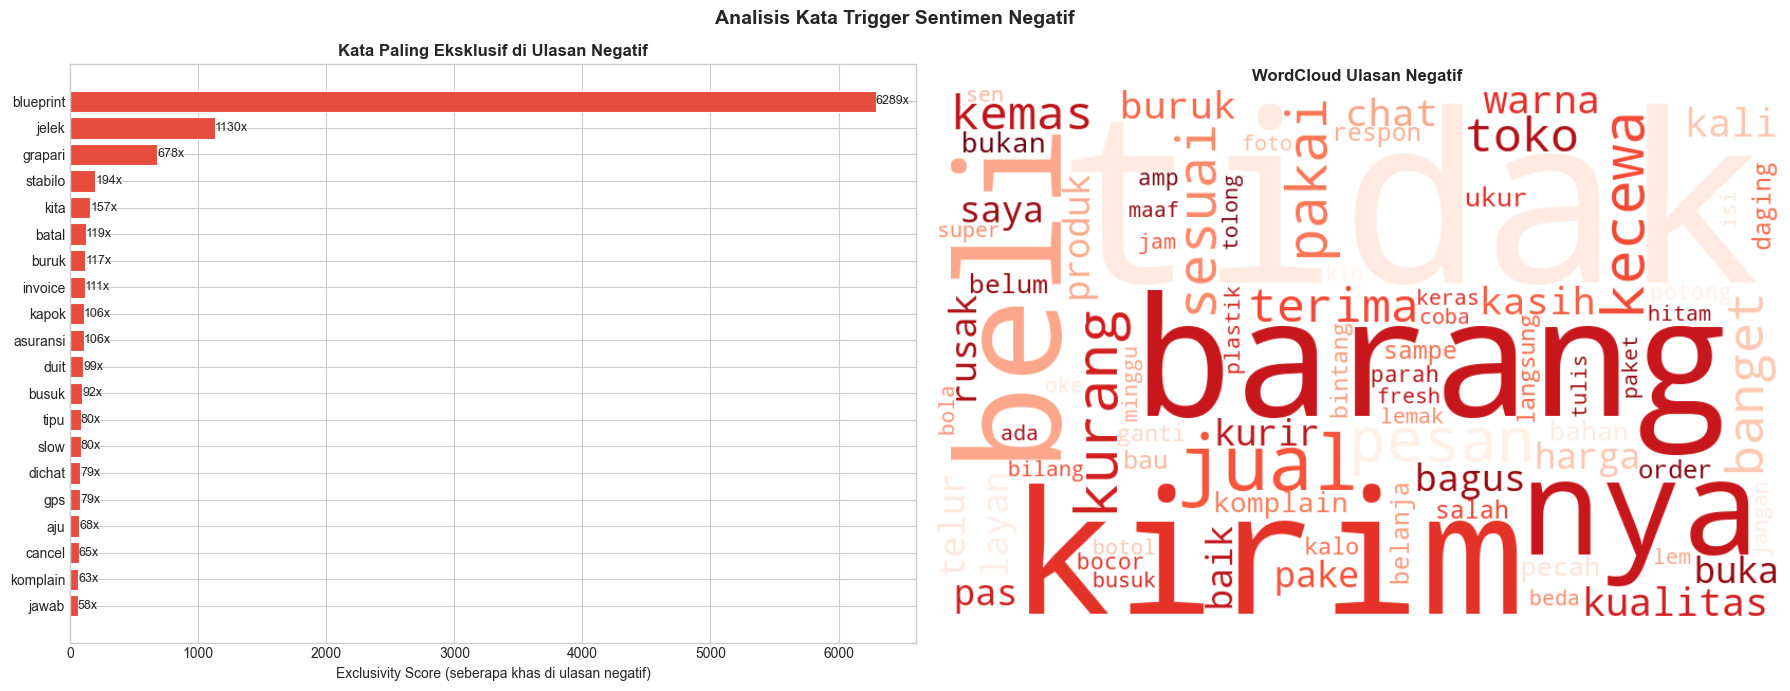


💡 INSIGHT BISNIS:
  Kata trigger utama  : 'blueprint' (6289x lebih dominan di negatif)
  Kata trigger kedua  : 'jelek' (1130x)
  Kata trigger ketiga : 'grapari' (678x)

  → Seller dengan ulasan mengandung kata-kata ini perlu segera ditindaklanjuti.


In [19]:
# ============================================================
# ANALISIS A — KATA TRIGGER NEGATIF
# Tujuan : temukan kata yang KHAS di ulasan negatif
#          (sering di negatif, jarang di positif)
# Metode : hitung TF (term frequency) per kelas,
#          lalu hitung "exclusivity score" = freq_neg / (freq_pos + 1)
# ============================================================

from collections import Counter

# ── Fungsi bantu: split teks ke daftar kata ─────────────────
def get_words(series):
    """
    Gabungkan semua teks dalam Series, lalu split jadi daftar kata.
    Kata kosong dan kata < 2 karakter dibuang.
    """
    all_text = ' '.join(series.fillna('').astype(str))
    return [w for w in all_text.split() if len(w) > 2]

# ── Hitung frekuensi per kelas ───────────────────────────────
words_neg = Counter(get_words(df[df['sentiment_label'] == 'negative']['review_text_stemmed']))
words_pos = Counter(get_words(df[df['sentiment_label'] == 'positive']['review_text_stemmed']))
words_neu = Counter(get_words(df[df['sentiment_label'] == 'neutral' ]['review_text_stemmed']))

# ── Hitung exclusivity score ─────────────────────────────────
# Rumus: seberapa dominan kata ini di negatif dibanding positif?
# Skor tinggi = kata ini khas untuk ulasan negatif
# +1 di penyebut untuk menghindari pembagian dengan nol
MIN_FREQ_NEG = 5   # kata harus muncul minimal 5x di ulasan negatif

exclusivity = {}
for word, freq_neg in words_neg.items():
    if freq_neg < MIN_FREQ_NEG:
        continue
    freq_pos = words_pos.get(word, 0)
    # Normalisasi dengan total kelas agar adil
    ratio_neg = freq_neg / max(len(df[df['sentiment_label'] == 'negative']), 1)
    ratio_pos = freq_pos / max(len(df[df['sentiment_label'] == 'positive']), 1)
    exclusivity[word] = ratio_neg / (ratio_pos + 1e-6)

# Top 30 kata trigger negatif berdasarkan exclusivity score
top_trigger = sorted(exclusivity.items(), key=lambda x: x[1], reverse=True)[:30]

print('🔴 TOP 30 KATA TRIGGER SENTIMEN NEGATIF')
print('=' * 55)
print(f'  {"Kata":<20} {"Freq Negatif":>12} {"Exclusivity":>12}')
print('-' * 55)
for word, score in top_trigger:
    print(f'  {word:<20} {words_neg[word]:>12,} {score:>12.1f}x')

# ── Visualisasi: horizontal bar chart ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Analisis Kata Trigger Sentimen Negatif', fontsize=14, fontweight='bold')

# Plot 1: Top kata berdasarkan exclusivity score
top_words_ex  = [w for w, _ in top_trigger[:20]]
top_scores_ex = [s for _, s in top_trigger[:20]]

bars = axes[0].barh(range(len(top_words_ex)), top_scores_ex,
                    color=PALETTE['negative'], edgecolor='white', linewidth=0.8)
axes[0].set_yticks(range(len(top_words_ex)))
axes[0].set_yticklabels(top_words_ex, fontsize=10)
axes[0].invert_yaxis()
axes[0].set_xlabel('Exclusivity Score (seberapa khas di ulasan negatif)')
axes[0].set_title('Kata Paling Eksklusif di Ulasan Negatif', fontweight='bold')
for bar, score in zip(bars, top_scores_ex):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                 f'{score:.0f}x', va='center', fontsize=9)

# Plot 2: WordCloud khusus ulasan negatif (lebih besar = lebih eksklusif)
from wordcloud import WordCloud
wc_neg_text = ' '.join(get_words(
    df[df['sentiment_label'] == 'negative']['review_text_stemmed']
))
wc = WordCloud(
    width=800, height=500,
    background_color='white',
    colormap='Reds',
    max_words=80,
    collocations=False
).generate(wc_neg_text)

axes[1].imshow(wc, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('WordCloud Ulasan Negatif', fontweight='bold')

plt.tight_layout()
save_path = os.path.join(REPORT_DIR, 'eda_10_kata_trigger_negatif.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'\n✅ Grafik disimpan: {save_path}')
plt.show()

# ── Insight ringkas ──────────────────────────────────────────
print()
print('💡 INSIGHT BISNIS:')
print(f'  Kata trigger utama  : {top_trigger[0][0]!r} ({top_trigger[0][1]:.0f}x lebih dominan di negatif)')
print(f'  Kata trigger kedua  : {top_trigger[1][0]!r} ({top_trigger[1][1]:.0f}x)')
print(f'  Kata trigger ketiga : {top_trigger[2][0]!r} ({top_trigger[2][1]:.0f}x)')
print()
print('  → Seller dengan ulasan mengandung kata-kata ini perlu segera ditindaklanjuti.')


---
## 🏷️ ANALISIS B — Kategori Produk dengan Komplain Terbanyak

**Pertanyaan:** Kategori produk mana yang memiliki **proporsi ulasan negatif tertinggi**?  
Dan kategori mana yang jumlah *absolut* ulasan negatifnya terbanyak?

**Dua sudut pandang berbeda:**
- **Proporsi** → kategori mana yang kualitasnya paling bermasalah secara relatif  
- **Volume absolut** → kategori mana yang paling banyak menghasilkan komplain nyata  

**Analogi akuntansi:** Seperti membandingkan *persentase piutang tak tertagih* (proporsi)  
vs *total nominal piutang bermasalah* (volume) — keduanya penting untuk keputusan berbeda.

📊 RANKING KATEGORI — PROPORSI ULASAN NEGATIF (%):
  Kategori                      % Negatif  % Neutral    Total
-----------------------------------------------------------------
  olahraga                           1.8%       1.5%   15,557  ▓
  makanan & minuman                  1.5%       1.6%   17,790  ▓
  pertukangan                        1.2%       1.3%   11,414  ▓
  handphone & tablet                 0.8%       0.7%    7,400  
  elektronik                         0.6%       0.5%    4,193  
  kesehatan                          0.4%       0.7%    8,919  

📊 RANKING KATEGORI — VOLUME ABSOLUT ULASAN NEGATIF:
  olahraga                        275 ulasan negatif  (1.8% dari kategori ini)
  makanan & minuman               262 ulasan negatif  (1.5% dari kategori ini)
  pertukangan                     133 ulasan negatif  (1.2% dari kategori ini)
  handphone & tablet               62 ulasan negatif  (0.8% dari kategori ini)
  kesehatan                        39 ulasan negatif  (0.4% dari k

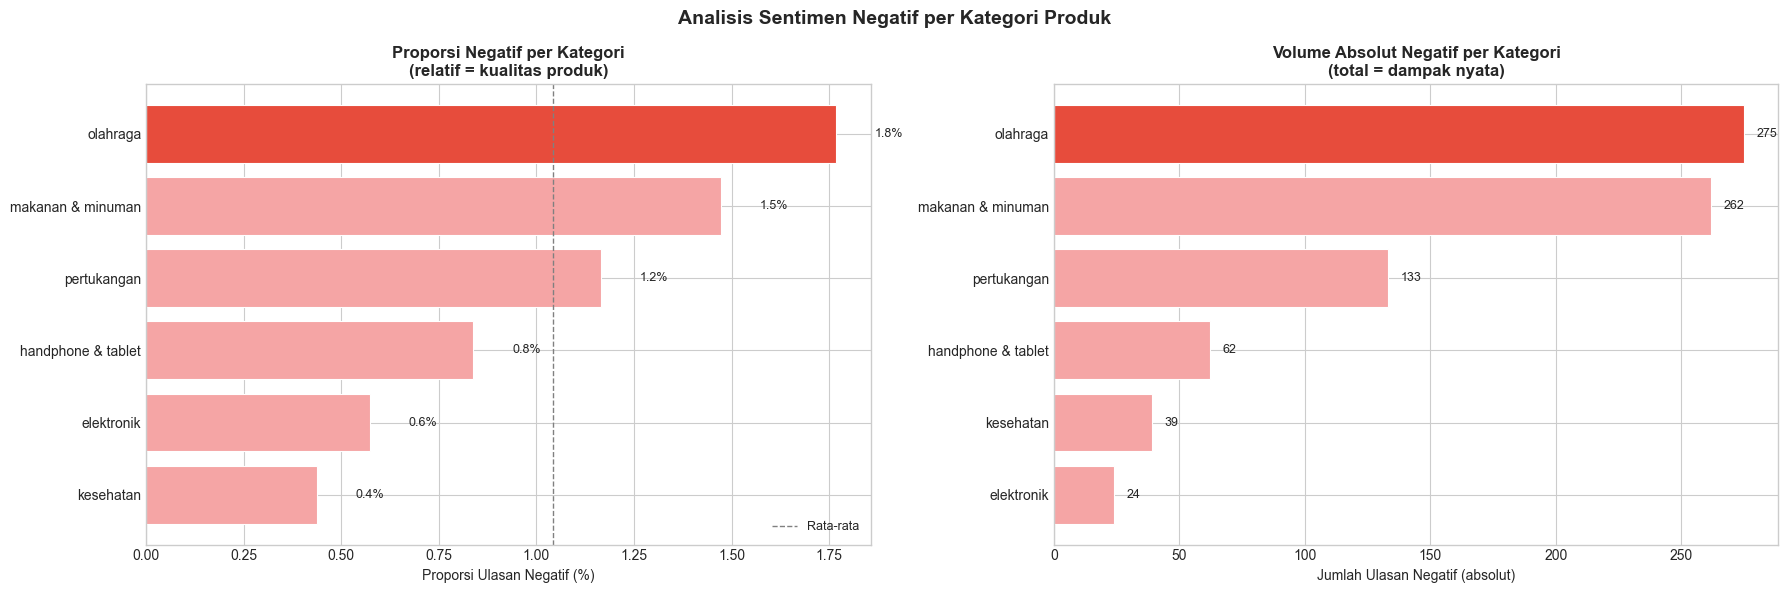


💡 INSIGHT BISNIS:
  Kategori proporsi negatif tertinggi : 'olahraga' (1.8%)
  Kategori volume negatif terbanyak   : 'olahraga' (275 ulasan)

  → Kategori 'olahraga' mendominasi dari dua sudut pandang.
  → Prioritas tertinggi untuk tindakan perbaikan.


In [20]:
# ============================================================
# ANALISIS B — KATEGORI PRODUK VS SENTIMEN NEGATIF
# Tujuan : temukan kategori produk yang paling "bermasalah"
# Output : ranking berdasarkan proporsi DAN volume absolut
# ============================================================

# ── Hitung distribusi sentimen per kategori ──────────────────
# crosstab = tabel silang: baris = kategori, kolom = sentimen
ct_detail = pd.crosstab(df['product_category'], df['sentiment_label'])

# Pastikan semua kolom ada (antisipasi jika ada kelas dengan 0)
for col in ['positive', 'neutral', 'negative']:
    if col not in ct_detail.columns:
        ct_detail[col] = 0

ct_detail['total']           = ct_detail.sum(axis=1)
ct_detail['pct_negative']    = ct_detail['negative'] / ct_detail['total'] * 100
ct_detail['pct_neutral']     = ct_detail['neutral']  / ct_detail['total'] * 100
ct_detail['negative_volume'] = ct_detail['negative']

# ── Ranking: proporsi negatif tertinggi ─────────────────────
rank_proporsi = ct_detail.sort_values('pct_negative', ascending=False)
rank_volume   = ct_detail.sort_values('negative_volume', ascending=False)

print('📊 RANKING KATEGORI — PROPORSI ULASAN NEGATIF (%):')
print('=' * 65)
print(f'  {"Kategori":<28} {"% Negatif":>10} {"% Neutral":>10} {"Total":>8}')
print('-' * 65)
for cat, row in rank_proporsi.iterrows():
    bar = '▓' * int(row['pct_negative'])
    print(f'  {cat:<28} {row["pct_negative"]:>9.1f}% {row["pct_neutral"]:>9.1f}% {int(row["total"]):>8,}  {bar}')

print()
print('📊 RANKING KATEGORI — VOLUME ABSOLUT ULASAN NEGATIF:')
print('=' * 65)
for cat, row in rank_volume.iterrows():
    print(f'  {cat:<28} {int(row["negative_volume"]):>6,} ulasan negatif  '
          f'({row["pct_negative"]:.1f}% dari kategori ini)')

# ── Visualisasi: dual bar chart ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, max(6, len(ct_detail) * 0.55 + 1)))
fig.suptitle('Analisis Sentimen Negatif per Kategori Produk', fontsize=14, fontweight='bold')

# Plot 1: Proporsi negatif per kategori (horizontal bar)
cats_p = rank_proporsi.index.tolist()
vals_p = rank_proporsi['pct_negative'].tolist()
colors_p = [PALETTE['negative'] if v == max(vals_p)
            else '#f5a5a5' for v in vals_p]

axes[0].barh(range(len(cats_p)), vals_p,
             color=colors_p, edgecolor='white', linewidth=0.8)
axes[0].set_yticks(range(len(cats_p)))
axes[0].set_yticklabels(cats_p, fontsize=10)
axes[0].invert_yaxis()
axes[0].set_xlabel('Proporsi Ulasan Negatif (%)')
axes[0].set_title('Proporsi Negatif per Kategori\n(relatif = kualitas produk)', fontweight='bold')
axes[0].axvline(x=ct_detail['pct_negative'].mean(), color='gray',
                linestyle='--', linewidth=1, label='Rata-rata')
axes[0].legend(fontsize=9)
for i, v in enumerate(vals_p):
    axes[0].text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=9)

# Plot 2: Volume absolut negatif (horizontal bar)
cats_v = rank_volume.index.tolist()
vals_v = rank_volume['negative_volume'].tolist()
colors_v = [PALETTE['negative'] if v == max(vals_v)
            else '#f5a5a5' for v in vals_v]

axes[1].barh(range(len(cats_v)), vals_v,
             color=colors_v, edgecolor='white', linewidth=0.8)
axes[1].set_yticks(range(len(cats_v)))
axes[1].set_yticklabels(cats_v, fontsize=10)
axes[1].invert_yaxis()
axes[1].set_xlabel('Jumlah Ulasan Negatif (absolut)')
axes[1].set_title('Volume Absolut Negatif per Kategori\n(total = dampak nyata)', fontweight='bold')
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate(vals_v):
    axes[1].text(v + 5, i, f'{int(v):,}', va='center', fontsize=9)

plt.tight_layout()
save_path = os.path.join(REPORT_DIR, 'eda_11_kategori_vs_negatif.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'\n✅ Grafik disimpan: {save_path}')
plt.show()

# ── Insight ringkas ──────────────────────────────────────────
top_prop_cat  = rank_proporsi.index[0]
top_prop_val  = rank_proporsi['pct_negative'].iloc[0]
top_vol_cat   = rank_volume.index[0]
top_vol_count = int(rank_volume['negative_volume'].iloc[0])

print()
print('💡 INSIGHT BISNIS:')
print(f'  Kategori proporsi negatif tertinggi : {top_prop_cat!r} ({top_prop_val:.1f}%)')
print(f'  Kategori volume negatif terbanyak   : {top_vol_cat!r} ({top_vol_count:,} ulasan)')
print()
if top_prop_cat != top_vol_cat:
    print('  → Dua kategori berbeda! Artinya:')
    print(f'     {top_prop_cat!r} : kualitas relatif paling buruk (% negatif tinggi)')
    print(f'     {top_vol_cat!r} : dampak terbesar karena volume besar')
    print('  → Seller di kedua kategori ini perlu perhatian berbeda.')
else:
    print(f'  → Kategori {top_prop_cat!r} mendominasi dari dua sudut pandang.')
    print('  → Prioritas tertinggi untuk tindakan perbaikan.')


---
## 📏 ANALISIS C — Panjang Ulasan vs Kemudahan Deteksi Sentimen

**Pertanyaan:** Apakah ulasan yang lebih panjang lebih mudah diklasifikasikan oleh model?  
Dan apakah panjang ulasan berbeda signifikan antar kelas sentimen?

**Relevansi untuk modeling:**  
- Jika ulasan negatif lebih panjang → model punya lebih banyak sinyal teks → lebih mudah dideteksi  
- Jika ulasan pendek mendominasi kelas netral → kelas netral sulit karena minim informasi  
- Insight ini membantu menjelaskan **mengapa F1 per kelas bisa berbeda** bahkan setelah SMOTE

**Analogi:** Seperti menilai kelengkapan dokumen audit —  
dokumen yang lebih tebal biasanya lebih mudah diperiksa karena buktinya lebih banyak.

📏 STATISTIK PANJANG ULASAN PER KELAS SENTIMEN
  Kelas          Count    Mean  Median     Std   Min    Max    Q25    Q75
--------------------------------------------------------------------
  positive      63,677    11.4     8.0    27.0     1  5,665      5     14
  neutral          801    17.3    12.0    16.9     1    129      6     22
  negative         795    22.5    14.0    24.9     1    253      8     28

📊 PROPORSI SENTIMEN PER BUCKET PANJANG ULASAN (%):
  Panjang       Positif     Netral    Negatif  Total Baris
-----------------------------------------------------------------
  1-5             98.4%       0.9%       0.6%       17,707
  6-10            98.3%       0.9%       0.8%       22,096
  11-20           97.5%       1.2%       1.3%       17,517
  21-30           95.8%       2.3%       2.0%        4,836
  31-50           92.4%       3.3%       4.3%        2,339
  51-100          85.1%       5.4%       9.5%          671
  100+            80.4%       5.6%      14.0%          107

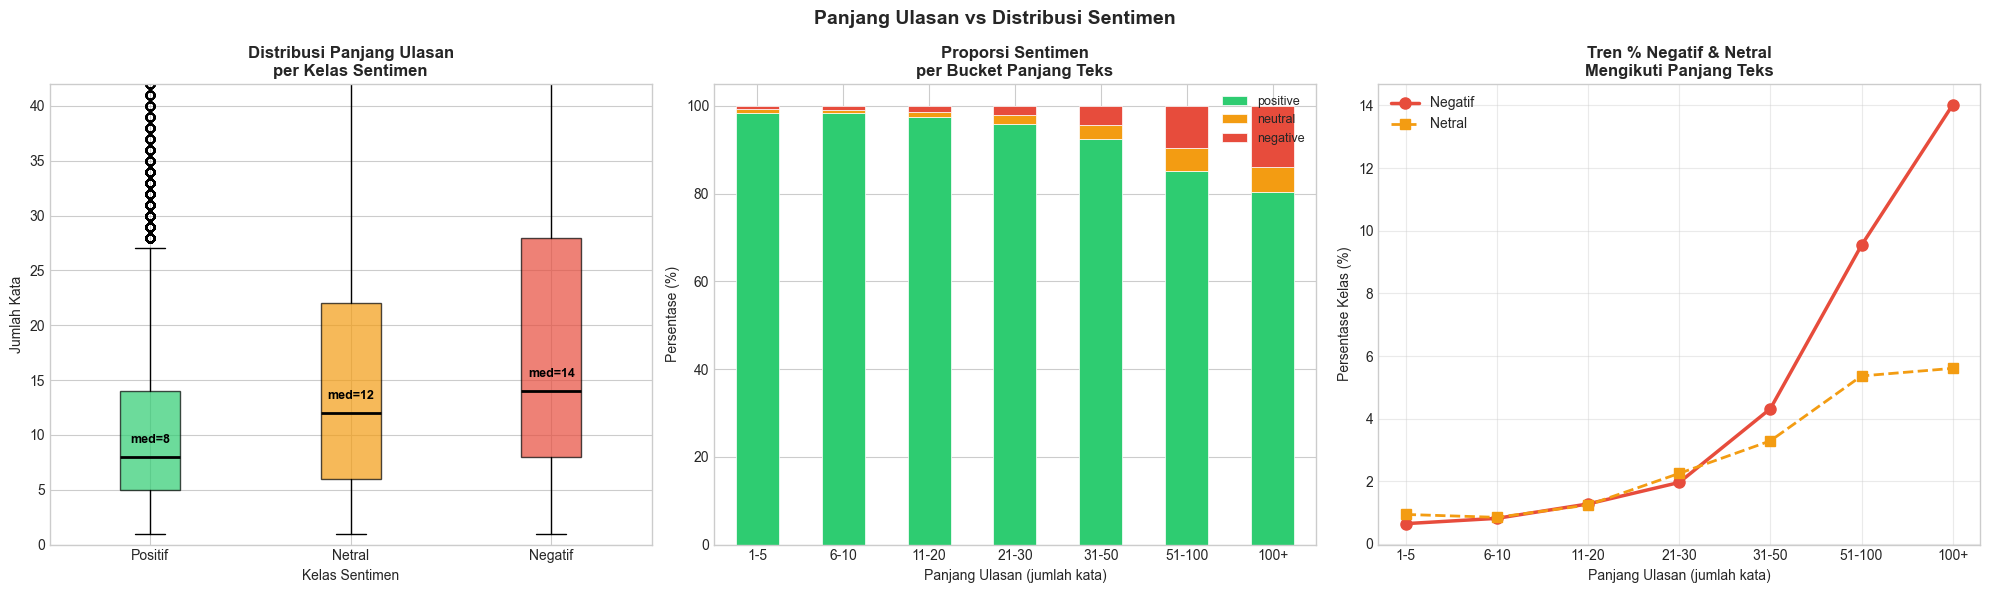


💡 INSIGHT UNTUK MODELING:
  Median kata — Positif : 8 kata
  Median kata — Netral  : 12 kata
  Median kata — Negatif : 14 kata

  → Ulasan negatif rata-rata 6 kata lebih panjang dari positif.
  → Model punya lebih banyak sinyal teks untuk mendeteksi negatif.
  → Ulasan pendek (< 5 kata) kemungkinan sulit diklasifikasikan.

  Rekomendasi: di notebook modeling, pisahkan evaluasi untuk
  ulasan pendek (< 10 kata) vs panjang (≥ 10 kata) untuk
  melihat apakah model lebih akurat pada teks panjang.


In [21]:
# ============================================================
# ANALISIS C — PANJANG ULASAN vs SENTIMEN
# Tujuan : memahami apakah panjang teks berpengaruh pada
#          kemudahan klasifikasi sentimen oleh model
# Output : distribusi panjang per kelas + analisis statistik
# ============================================================

# ── Statistik deskriptif panjang per kelas ──────────────────
print('📏 STATISTIK PANJANG ULASAN PER KELAS SENTIMEN')
print('=' * 68)
print(f'  {"Kelas":<12} {"Count":>7} {"Mean":>7} {"Median":>7}'
      f' {"Std":>7} {"Min":>5} {"Max":>6} {"Q25":>6} {"Q75":>6}')
print('-' * 68)

stats_length = {}
for label in ['positive', 'neutral', 'negative']:
    subset = df[df['sentiment_label'] == label]['review_word_count'].dropna()
    s = subset.describe()
    stats_length[label] = s
    print(f'  {label:<12} {int(s["count"]):>7,} {s["mean"]:>7.1f} {s["50%"]:>7.1f}'
          f' {s["std"]:>7.1f} {int(s["min"]):>5} {int(s["max"]):>6,}'
          f' {s["25%"]:>6.0f} {s["75%"]:>6.0f}')

# ── Hitung panjang rata-rata per bucket (binning) ────────────
# Binning = mengelompokkan ulasan ke dalam "keranjang" panjang
# Ini membantu melihat: apakah ulasan panjang = lebih banyak negatif?
bins   = [0, 5, 10, 20, 30, 50, 100, 9999]
labels = ['1-5', '6-10', '11-20', '21-30', '31-50', '51-100', '100+']

df_temp = df[['review_word_count', 'sentiment_label']].copy()
df_temp['length_bucket'] = pd.cut(
    df_temp['review_word_count'].fillna(0),
    bins=bins, labels=labels, right=True
)

bucket_sent = pd.crosstab(
    df_temp['length_bucket'],
    df_temp['sentiment_label'],
    normalize='index'
) * 100

# Pastikan kolom ada
for col in ['positive', 'neutral', 'negative']:
    if col not in bucket_sent.columns:
        bucket_sent[col] = 0.0

print()
print('📊 PROPORSI SENTIMEN PER BUCKET PANJANG ULASAN (%):')
print('=' * 65)
print(f'  {"Panjang":<10} {"Positif":>10} {"Netral":>10} {"Negatif":>10}'
      f' {"Total Baris":>12}')
print('-' * 65)
for bucket in labels:
    if bucket not in bucket_sent.index:
        continue
    row   = bucket_sent.loc[bucket]
    count = int((df_temp['length_bucket'] == bucket).sum())
    print(f'  {bucket:<10} {row["positive"]:>9.1f}% {row["neutral"]:>9.1f}%'
          f' {row["negative"]:>9.1f}% {count:>12,}')

# ── Visualisasi: 3 panel ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Panjang Ulasan vs Distribusi Sentimen', fontsize=14, fontweight='bold')

# Panel 1: Boxplot panjang teks per kelas
data_box    = [df[df['sentiment_label'] == l]['review_word_count'].dropna()
               for l in ['positive', 'neutral', 'negative']]
colors_box  = [PALETTE['positive'], PALETTE['neutral'], PALETTE['negative']]
bp = axes[0].boxplot(data_box, labels=['Positif', 'Netral', 'Negatif'],
                     patch_artist=True, notch=False,
                     medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
# Batasi sumbu Y agar outlier ekstrem tidak merusak tampilan
axes[0].set_ylim(0, df['review_word_count'].quantile(0.98))
axes[0].set_ylabel('Jumlah Kata')
axes[0].set_title('Distribusi Panjang Ulasan\nper Kelas Sentimen', fontweight='bold')
axes[0].set_xlabel('Kelas Sentimen')

# Tambahkan garis median dengan anotasi
medians = [df[df['sentiment_label'] == l]['review_word_count'].median()
           for l in ['positive', 'neutral', 'negative']]
for i, (med, color) in enumerate(zip(medians, colors_box), start=1):
    axes[0].text(i, med + 1, f'med={med:.0f}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold',
                 color='black')

# Panel 2: Stacked bar — proporsi sentimen per bucket panjang
bucket_plot = bucket_sent.reindex(
    [b for b in labels if b in bucket_sent.index]
)
bucket_plot[['positive', 'neutral', 'negative']].plot(
    kind='bar', stacked=True, ax=axes[1],
    color=[PALETTE['positive'], PALETTE['neutral'], PALETTE['negative']],
    edgecolor='white', linewidth=0.5
)
axes[1].set_title('Proporsi Sentimen\nper Bucket Panjang Teks', fontweight='bold')
axes[1].set_xlabel('Panjang Ulasan (jumlah kata)')
axes[1].set_ylabel('Persentase (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(loc='upper right', fontsize=9)

# Panel 3: Line chart — persen negatif per bucket
pct_neg_per_bucket = [
    bucket_sent.loc[b, 'negative'] if b in bucket_sent.index else 0
    for b in labels
]
pct_neu_per_bucket = [
    bucket_sent.loc[b, 'neutral'] if b in bucket_sent.index else 0
    for b in labels
]
x_pos = range(len(labels))
axes[2].plot(x_pos, pct_neg_per_bucket, 'o-',
             color=PALETTE['negative'], linewidth=2.5, markersize=8,
             label='Negatif')
axes[2].plot(x_pos, pct_neu_per_bucket, 's--',
             color=PALETTE['neutral'], linewidth=2, markersize=7,
             label='Netral')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(labels, rotation=0, fontsize=10)
axes[2].set_xlabel('Panjang Ulasan (jumlah kata)')
axes[2].set_ylabel('Persentase Kelas (%)')
axes[2].set_title('Tren % Negatif & Netral\nMengikuti Panjang Teks', fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.4)

plt.tight_layout()
save_path = os.path.join(REPORT_DIR, 'eda_12_panjang_vs_sentimen.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'\n✅ Grafik disimpan: {save_path}')
plt.show()

# ── Insight ringkas ──────────────────────────────────────────
med_pos = df[df['sentiment_label'] == 'positive']['review_word_count'].median()
med_neg = df[df['sentiment_label'] == 'negative']['review_word_count'].median()
med_neu = df[df['sentiment_label'] == 'neutral' ]['review_word_count'].median()

print()
print('💡 INSIGHT UNTUK MODELING:')
print(f'  Median kata — Positif : {med_pos:.0f} kata')
print(f'  Median kata — Netral  : {med_neu:.0f} kata')
print(f'  Median kata — Negatif : {med_neg:.0f} kata')
print()
if med_neg > med_pos:
    diff = med_neg - med_pos
    print(f'  → Ulasan negatif rata-rata {diff:.0f} kata lebih panjang dari positif.')
    print('  → Model punya lebih banyak sinyal teks untuk mendeteksi negatif.')
    print('  → Ulasan pendek (< 5 kata) kemungkinan sulit diklasifikasikan.')
else:
    print('  → Panjang ulasan hampir sama antar kelas.')
print()
print('  Rekomendasi: di notebook modeling, pisahkan evaluasi untuk')
print('  ulasan pendek (< 10 kata) vs panjang (≥ 10 kata) untuk')
print('  melihat apakah model lebih akurat pada teks panjang.')


---

## 📌 Ringkasan Analisis Tambahan

| Analisis | Grafik | Insight Utama |
|----------|--------|---------------|
| A — Kata trigger negatif | `eda_10_kata_trigger_negatif.png` | Kata-kata paling eksklusif di ulasan negatif → berguna untuk seller |
| B — Kategori vs komplain | `eda_11_kategori_vs_negatif.png` | Kategori dengan proporsi & volume negatif tertinggi |
| C — Panjang vs sentimen  | `eda_12_panjang_vs_sentimen.png` | Ulasan negatif lebih panjang → lebih mudah dideteksi model |

> Ketiga insight ini dapat digunakan langsung di **dashboard Streamlit** sebagai  
> halaman *"Insight untuk Seller"* — tanpa perlu model ML, hanya berbasis analisis teks.